# Аудит официального датасета Мостранспорта

**Тип документа:** evidence notebook (доказательная фиксация фактов о данных).
**Версия:** remediation pass после независимого аудита (v1 → v1.1).

**Цель.** Перед фиксацией ML Strategy v1 нужно опереться не на предположения из
предыдущей документации репозитория, а на реальный официальный датасет
организаторов. Этот notebook — единственный источник истины по фактам о
датасете: для каждого существенного утверждения ниже есть вычислительная
опора (код → результат → вывод → статус доказательства).

**Дата исследования:** 2026-09-25.

**Как читать.** Каждый раздел построен по схеме:

> ВОПРОС / ГИПОТЕЗА → метод проверки → вычисление → график/таблица → результат → вывод → статус

Статусы, используемые в этом notebook:

- **ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ** — факт заявлен в официальном README датасета;
- **ДОКАЗАНО ДАННЫМИ** — мы вычислили это сами и получили однозначный результат;
- **НЕ ПОДТВЕРЖДЕНО** — гипотеза не подтвердилась вычислением;
- **ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ** — разумная идея, требующая эксперимента с моделью;
- **ЗАПРЕЩЕНО ИЗ-ЗА УТЕЧКИ** — источник данных нельзя использовать по правилам хакатона.

`train`/`test`/`validate` трактуются строго по официальному README организаторов
(`dataset/README.md`), а не по более ранним записям в `docs/` этого репозитория.

---

> ⚠️ **ВАЖНО — точная формулировка leakage-инварианта (см. также раздел 9).**
> Ради проверки семантики target (раздел 6) этот notebook **закономерно
> загружает** `test/schedule.csv` целиком, включая факт (`time_fact_begin`), —
> это официальный test-артефакт, разрешённый для train/test-анализа. Раздел 9
> отдельно доказывает, что те же самые schedule-actions из `test/schedule.csv`
> соответствуют целевым точкам `validate/points.csv`, а значит теоретически
> позволяют восстановить скрытый target `validate`. **Мы формулируем гарантию
> точно:** hidden validate target нигде в этом notebook **не вычислялся, не
> восстанавливался, не join'ился с `validate/points.csv`, не выводился и не
> использовался** для анализа или предсказания — а не то, что колонка
> `time_fact_begin` "никогда не читалась" (она читалась, но только в
> train/test-контексте). Эта гарантия проверяется явно в финальной ячейке
> notebook.

## 1. Конфигурация и воспроизводимость

Путь к датасету задаётся переменной окружения `MOSTRANSPORT_DATASET`; если она
не задана — используется локальный путь как fallback (актуально только для
машины исследователя, сам датасет в репозиторий не входит и не коммитится).

In [1]:
%matplotlib inline

import hashlib
import os
import platform
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_ROOT = Path(
    os.environ.get(
        "MOSTRANSPORT_DATASET",
        "/home/fz/projects/Предиктор задержек транспорта/"
        "Предиктор задержек транспорта/dataset",
    )
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100

print("DATASET_ROOT:", DATASET_ROOT)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

DATASET_ROOT: /home/fz/projects/Предиктор задержек транспорта/Предиктор задержек транспорта/dataset
Python: 3.12.3
Platform: Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
pandas: 3.0.6
numpy: 2.5.3
matplotlib: 3.11.2


In [2]:
def sha256_of(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


EXPECTED_FILES = {
    "train/traffic.csv": 287849,
    "train/schedule.csv": 16674,
    "labels/labels_train.csv": 4434,
    "test/traffic.csv": 105945,
    "test/schedule.csv": 5558,
    "labels/labels_test.csv": 353,
    "validate/traffic.csv": 105945,
    "validate/schedule_plan.csv": 5558,
    "validate/points.csv": 151,
    "sample_submission.csv": None,
}

inventory_rows = []
for rel_path, expected_rows in EXPECTED_FILES.items():
    full_path = DATASET_ROOT / rel_path
    exists = full_path.exists()
    size_bytes = full_path.stat().st_size if exists else None
    inventory_rows.append({
        "file": rel_path,
        "exists": exists,
        "size_bytes": size_bytes,
        "size_mb": round(size_bytes / 1_048_576, 2) if size_bytes else None,
    })

inventory_df = pd.DataFrame(inventory_rows)
assert inventory_df["exists"].all(), "Не найдены ожидаемые файлы датасета — см. таблицу выше."
inventory_df

,file,exists,size_bytes,size_mb
0,train/traffic.csv,True,49170493,46.89
1,train/schedule.csv,True,2690246,2.57
2,labels/labels_train.csv,True,463478,0.44
3,test/traffic.csv,True,17117773,16.32
4,test/schedule.csv,True,794336,0.76
5,labels/labels_test.csv,True,33775,0.03
6,validate/traffic.csv,True,17117773,16.32
7,validate/schedule_plan.csv,True,683160,0.65
8,validate/points.csv,True,12645,0.01
9,sample_submission.csv,True,3696,0.00


### 1.1. Полный fingerprint официального dataset snapshot (R6)

SHA-256 всех содержательных файлов раздачи — это отпечаток конкретной версии
датасета, на которой построен весь анализ ниже. Если организаторы обновят
датасет, эту таблицу нужно пересчитать и свериться.

Docker-образ эмулятора (`ndtp-telemetry-emulator.tar`, ~128 МБ) для полноты
тоже хешируется — на этом датасете хеширование занимает менее секунды,
заметно не увеличивая время выполнения notebook.

In [3]:
FINGERPRINT_FILES = [
    "README.md",
    "sample_submission.csv",
    "train/traffic.csv",
    "train/schedule.csv",
    "labels/labels_train.csv",
    "test/traffic.csv",
    "test/schedule.csv",
    "labels/labels_test.csv",
    "validate/traffic.csv",
    "validate/schedule_plan.csv",
    "validate/points.csv",
    "docs/Emulator-and-Telematic-Packets-Specification.md",
    "ndtp-telemetry-emulator.tar",
]

t0 = time.time()
fingerprint_rows = []
for rel_path in FINGERPRINT_FILES:
    full_path = DATASET_ROOT / rel_path
    fingerprint_rows.append({
        "relative_path": rel_path,
        "bytes": full_path.stat().st_size,
        "sha256": sha256_of(full_path),
    })
fingerprint_df = pd.DataFrame(fingerprint_rows)
print(f"Fingerprint посчитан за {time.time() - t0:.2f} c для {len(fingerprint_rows)} файлов.")
fingerprint_df

Fingerprint посчитан за 0.27 c для 13 файлов.


,relative_path,bytes,sha256
0,README.md,12870,5ea48be369a9f512d452e2a5c78702e3969aa8982016b7...
1,sample_submission.csv,3696,e288c1e332bc3ce157f630b155601f8d43d02bcc3bd7e9...
2,train/traffic.csv,49170493,1890b36e19765c970b3db3c15fc372e2c6dfcc2b203806...
3,train/schedule.csv,2690246,f7c109efd50d358d202b6c1fc5a7cb5be14ccc489c7adb...
4,labels/labels_train.csv,463478,b3058d52683091e77d190d6a99b717ad5c44ae02de37ca...
5,test/traffic.csv,17117773,3c74bb9d3cc5e076a2e7f89de7e78fb103c350757d16c9...
6,test/schedule.csv,794336,a31023b3ec29942145e31ef0eb93bc5ef4adf49b2d9da5...
7,labels/labels_test.csv,33775,7c7b0206d7ee6ee66af6baafba311755d5e033cd291410...
8,validate/traffic.csv,17117773,3c74bb9d3cc5e076a2e7f89de7e78fb103c350757d16c9...
9,validate/schedule_plan.csv,683160,c9b561743a5cb83616941b02b47c5aded89e75218d93c1...


## 2. Официальная постановка Data Science задачи

Ниже — **дословно проверяемые факты из `dataset/README.md`** организаторов
(не наши предположения).

- **Точка прогноза** — пара `(tr_id, T)`: телеметрия ТС `tr_id` известна вплоть
  до момента `T`.
- **Anti-leakage правило:** для прогноза в момент `T` разрешена только
  телеметрия с `event_time ≤ T`, плюс подсказка `cur_dev_s` (известна на `T`).
- **Target** — `target_delay_s`: фактическая задержка (в секундах) на первой
  остановке, чьё **плановое** время прибытия попадает в окно `(T+10 мин, T+15 мин]`.
- **Задержка = факт − план.** Положительная величина — опоздание, отрицательная — опережение.
- **`target_class`** (`early`/`ontime`/`late`, пороги −60 c / +120 c) — справочная
  характеристика, **не** является leaderboard-таргетом.
- **`cur_dev_s`** — задержка на последней уже пройденной остановке, известна на момент `T`.
- **Формат submission** — `sample_id;prediction`, разделитель `;`, ровно две колонки.
- **Метрика** — MAE (mean absolute error), в секундах.
- **Официальное заявление организаторов:** `sample_submission.csv` — это
  baseline «прогноз = `cur_dev_s`», который даёт **≈ 0.40** по их формуле
  score. *(Само число `score ≈ 0.40` — заявление организаторов о их закрытом
  leaderboard, мы не можем и не пытаемся его локально проверить, поскольку
  оно считается на скрытом ground truth `validate`. То, что
  `sample_submission.csv` **структурно реализует** `prediction = cur_dev_s`,
  мы проверяем и подтверждаем данными в разделе 4.2.)*
- **Организаторы заявляют**, что в `train` добавлены синтетические ТС "для
  объёма"; `test` и `validate` — полностью реальные. Мы проверяем это
  вычислением в разделах 7–8, но с важной оговоркой про то, *какая именно*
  часть `tr_id` синтетическая — README не называет конкретный диапазон ID
  (см. раздел 8).

**Статус: ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ** (source: `dataset/README.md`).

## 3. Инвентаризация файлов и схем

**Вопрос:** соответствует ли фактический состав файлов и их размер тому, что
заявлено в README, и совпадают ли row count'ы с ранее зафиксированными
контрольными значениями?

**Метод:** прочитать каждый файл, вывести схему, число строк, missingness по
ключевым колонкам.

In [4]:
TRAFFIC_DTYPES = {
    "packet_id": "string",  # большие int64 packet_id иногда дают mixed dtype при chunked-чтении — читаем как string
    "tr_id": "int64",
    "unit_id": "int64",
    "device_event_id": "int64",
    "location_valid": "boolean",
    "lon": "float64",
    "lat": "float64",
    "alt": "float64",
    "speed": "float64",
    "heading": "float64",
    "is_hist_data": "boolean",
}


def load_traffic(rel_path: str) -> pd.DataFrame:
    return pd.read_csv(
        DATASET_ROOT / rel_path,
        dtype=TRAFFIC_DTYPES,
        parse_dates=["event_time", "gps_time", "receive_time"],
    )


def load_schedule(rel_path: str, has_fact: bool = True) -> pd.DataFrame:
    parse_dates = ["time_begin", "order_date"] + (["time_fact_begin"] if has_fact else [])
    return pd.read_csv(DATASET_ROOT / rel_path, parse_dates=parse_dates)


def load_points(rel_path: str) -> pd.DataFrame:
    return pd.read_csv(DATASET_ROOT / rel_path, parse_dates=["T", "target_time_begin"])


train_traffic = load_traffic("train/traffic.csv")
test_traffic = load_traffic("test/traffic.csv")
validate_traffic = load_traffic("validate/traffic.csv")

# Загружаем test/schedule.csv целиком, включая факт (time_fact_begin) — это
# официальный test-артефакт, разрешённый для train/test-анализа (раздел 6).
# Мы НЕ связываем эти факты с validate нигде далее — см. предупреждение выше
# и явную проверку этого инварианта в финальной ячейке notebook.
train_schedule = load_schedule("train/schedule.csv", has_fact=True)
test_schedule = load_schedule("test/schedule.csv", has_fact=True)
validate_schedule_plan = load_schedule("validate/schedule_plan.csv", has_fact=False)

labels_train = load_points("labels/labels_train.csv")
labels_test = load_points("labels/labels_test.csv")
validate_points = load_points("validate/points.csv")

sample_submission = pd.read_csv(DATASET_ROOT / "sample_submission.csv", sep=";")

print("Файлы загружены без ошибок.")

Файлы загружены без ошибок.


In [5]:
EXPECTED_ROWS = {
    "train/traffic.csv": 287849,
    "train/schedule.csv": 16674,
    "labels/labels_train.csv": 4434,
    "test/traffic.csv": 105945,
    "test/schedule.csv": 5558,
    "labels/labels_test.csv": 353,
    "validate/traffic.csv": 105945,
    "validate/schedule_plan.csv": 5558,
    "validate/points.csv": 151,
}

DATASETS = {
    "train/traffic.csv": train_traffic,
    "train/schedule.csv": train_schedule,
    "labels/labels_train.csv": labels_train,
    "test/traffic.csv": test_traffic,
    "test/schedule.csv": test_schedule,
    "labels/labels_test.csv": labels_test,
    "validate/traffic.csv": validate_traffic,
    "validate/schedule_plan.csv": validate_schedule_plan,
    "validate/points.csv": validate_points,
    "sample_submission.csv": sample_submission,
}

schema_rows = []
for name, df in DATASETS.items():
    key_cols = [c for c in ["tr_id", "sample_id", "tt_action_item_id"] if c in df.columns]
    schema_rows.append({
        "file": name,
        "rows": len(df),
        "columns": len(df.columns),
        "key_columns": ", ".join(key_cols),
        "missing_any_pct": round(100 * df.isna().any(axis=1).mean(), 2),
    })

schema_df = pd.DataFrame(schema_rows)
schema_df

,file,rows,columns,key_columns,missing_any_pct
0,train/traffic.csv,287849,14,tr_id,5.73
1,train/schedule.csv,16674,8,"tr_id, tt_action_item_id",17.54
2,labels/labels_train.csv,4434,8,"tr_id, sample_id",0.00
3,test/traffic.csv,105945,14,tr_id,6.18
4,test/schedule.csv,5558,8,"tr_id, tt_action_item_id",17.54
5,labels/labels_test.csv,353,8,"tr_id, sample_id",0.00
6,validate/traffic.csv,105945,14,tr_id,6.18
7,validate/schedule_plan.csv,5558,7,"tr_id, tt_action_item_id",17.54
8,validate/points.csv,151,6,"tr_id, sample_id",0.00
9,sample_submission.csv,151,2,sample_id,0.00


In [6]:
print("Проверка row count против контрольных значений:")
all_match = True
for rel_path, expected in EXPECTED_ROWS.items():
    actual = len(DATASETS[rel_path])
    ok = actual == expected
    all_match &= ok
    status = "OK" if ok else f"РАСХОЖДЕНИЕ (ожидалось {expected})"
    print(f"  {rel_path:32s} actual={actual:<8d} {status}")

assert all_match, "Row count разошёлся с контрольными значениями — см. вывод выше."
print()
print("Вывод: все row count совпадают с контрольными значениями.")
print("Статус: ДОКАЗАНО ДАННЫМИ")

Проверка row count против контрольных значений:
  train/traffic.csv                actual=287849   OK
  train/schedule.csv               actual=16674    OK
  labels/labels_train.csv          actual=4434     OK
  test/traffic.csv                 actual=105945   OK
  test/schedule.csv                actual=5558     OK
  labels/labels_test.csv           actual=353      OK
  validate/traffic.csv             actual=105945   OK
  validate/schedule_plan.csv       actual=5558     OK
  validate/points.csv              actual=151      OK

Вывод: все row count совпадают с контрольными значениями.
Статус: ДОКАЗАНО ДАННЫМИ


## 4. Доказательство competition protocol

**Вопрос:** действительно ли задача — regression по `target_delay_s` с метрикой
MAE, и действительно ли `validate` не содержит скрытый target ни в каком виде?

**Метод:** программные assertions по ключевым инвариантам протокола.

In [7]:
checks = {}

checks["sample_id unique (train)"] = labels_train["sample_id"].is_unique
checks["sample_id unique (test)"] = labels_test["sample_id"].is_unique
checks["sample_id unique (validate)"] = validate_points["sample_id"].is_unique

checks["target_stop_id present everywhere"] = all(
    "target_stop_id" in df.columns for df in [labels_train, labels_test, validate_points]
)
checks["cur_dev_s present everywhere"] = all(
    "cur_dev_s" in df.columns for df in [labels_train, labels_test, validate_points]
)

checks["validate НЕ содержит target_delay_s"] = "target_delay_s" not in validate_points.columns
checks["validate НЕ содержит target_class"] = "target_class" not in validate_points.columns
checks["validate/schedule_plan.csv НЕ содержит time_fact_begin"] = (
    "time_fact_begin" not in validate_schedule_plan.columns
)

checks["submission — ровно колонки sample_id;prediction"] = list(sample_submission.columns) == [
    "sample_id",
    "prediction",
]
checks["submission без дублей sample_id"] = sample_submission["sample_id"].is_unique
checks["submission полностью покрывает validate sample_id"] = set(
    sample_submission["sample_id"]
) == set(validate_points["sample_id"])

for name, ok in checks.items():
    print(f"{'OK ' if ok else 'FAIL'}  {name}")

assert all(checks.values()), "Хотя бы один инвариант протокола нарушен — см. вывод выше."

OK   sample_id unique (train)
OK   sample_id unique (test)
OK   sample_id unique (validate)
OK   target_stop_id present everywhere
OK   cur_dev_s present everywhere
OK   validate НЕ содержит target_delay_s
OK   validate НЕ содержит target_class
OK   validate/schedule_plan.csv НЕ содержит time_fact_begin
OK   submission — ровно колонки sample_id;prediction
OK   submission без дублей sample_id
OK   submission полностью покрывает validate sample_id


**Вывод:** соревновательный протокол — regression по `target_delay_s`;
`validate` действительно не содержит ни `target_delay_s`, ни
`target_class`, ни `time_fact_begin` ни в одном из выданных файлов
(`validate/traffic.csv`, `validate/schedule_plan.csv`, `validate/points.csv`).
`sample_submission.csv` — валидный шаблон, полностью покрывающий все
`sample_id` из `validate/points.csv` без дублей.

**Статус (структурные assertions протокола выше): ДОКАЗАНО ДАННЫМИ**

Метрика **MAE** упомянута здесь только как контекст: то, что leaderboard
использует именно MAE, — это заявление организаторов из README (§2), и
notebook его не "доказывает данными" (сам выбор метрики не является
вычислимым фактом) — ниже мы лишь воспроизводим *значения* baseline MAE
(§11), что не то же самое, что подтверждение выбора метрики.

**Статус (MAE как официальная метрика): ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ**

### 4.2. `sample_submission.csv` реализует baseline `prediction = cur_dev_s` (R7)

Это безопасная проверка: она использует **только** `sample_submission.csv` и
`validate/points.csv`, соединённые по `sample_id`. Никакой target, никакой
`test/schedule.csv` здесь не участвует.

In [8]:
submission_check = sample_submission.merge(
    validate_points[["sample_id", "cur_dev_s"]], on="sample_id", how="outer", indicator=True
)

n_both = int((submission_check["_merge"] == "both").sum())
n_only_left = int((submission_check["_merge"] == "left_only").sum())
n_only_right = int((submission_check["_merge"] == "right_only").sum())

print(f"строк sample_submission: {len(sample_submission)}   строк validate/points: {len(validate_points)}")
print(f"merge: both={n_both}  only_in_submission={n_only_left}  only_in_validate_points={n_only_right}")
print("sample_id дублируется в submission:", sample_submission["sample_id"].duplicated().any())
print("sample_id дублируется в validate_points:", validate_points["sample_id"].duplicated().any())

max_abs_diff = (submission_check["prediction"] - submission_check["cur_dev_s"]).abs().max()
all_equal = bool((submission_check["prediction"] == submission_check["cur_dev_s"]).all())
print("max |prediction - cur_dev_s| =", max_abs_diff)
print("prediction == cur_dev_s для всех строк:", all_equal)

assert n_both == len(validate_points) == len(sample_submission), "Coverage sample_submission ≠ validate/points"
assert n_only_left == 0 and n_only_right == 0, "Обнаружено расхождение множеств sample_id"
assert all_equal, "sample_submission.prediction НЕ равен cur_dev_s хотя бы для одной строки"

строк sample_submission: 151   строк validate/points: 151
merge: both=151  only_in_submission=0  only_in_validate_points=0
sample_id дублируется в submission: False
sample_id дублируется в validate_points: False
max |prediction - cur_dev_s| = 0.0
prediction == cur_dev_s для всех строк: True


**Вывод:** `sample_submission.csv` даёт 1:1 покрытие всех 151 `sample_id` из
`validate/points.csv` без дублей и пропусков, и `prediction` **точно равен**
`cur_dev_s` для каждой строки (max abs diff = 0). Утверждение "sample_submission
реализует baseline prediction = cur_dev_s" теперь подтверждено не только
текстом README, но и прямым вычислением на официальных файлах.

Заявленный организаторами score этого baseline (`≈0.40`) по-прежнему остаётся
**только заявлением README** — мы не можем пересчитать сам `score`, поскольку
он требует скрытого ground truth `validate`, которого у нас нет и не будет.

**Статус: ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ (сам факт baseline) + ДОКАЗАНО ДАННЫМИ
(структурное равенство `prediction == cur_dev_s`)**

## 5. Проверка горизонта прогнозирования

**Вопрос:** действительно ли `horizon_minutes = (target_time_begin − T) / 60`
всегда лежит в `(10, 15]` минут, как заявлено в README, и одинаково ли
распределён horizon в `train`/`test`/`validate`?

**Метод:** вычислить horizon для каждой точки, проверить assertion `10 <
horizon ≤ 15` для каждой точки без исключений, построить распределения.

**Важная оговорка (R10):** этот раздел доказывает только **геометрию**
целевого окна (какая именно остановка считается целью прогноза) — то, что
`10 < horizon ≤ 15` всегда выполняется. Он **не** доказывает leakage-safety
всего будущего feature pipeline: то, что признаки реально считаются только по
`event_time ≤ T`, — отдельная гарантия, которая проверяется в разделе 14.

In [9]:
def horizon_minutes(df: pd.DataFrame) -> pd.Series:
    return (df["target_time_begin"] - df["T"]).dt.total_seconds() / 60


horizon = {
    "train": horizon_minutes(labels_train),
    "test": horizon_minutes(labels_test),
    "validate": horizon_minutes(validate_points),
}

for name, h in horizon.items():
    ok = ((h > 10) & (h <= 15)).all()
    print(f"{name}: n={len(h)}  mean={h.mean():.4f}  min={h.min():.4f}  max={h.max():.4f}  "
          f"все в (10,15]: {ok}")
    assert ok, f"horizon вне (10,15] обнаружен в {name}"

train: n=4434  mean=11.2176  min=10.0516  max=15.0000  все в (10,15]: True
test: n=353  mean=11.5609  min=11.0000  max=15.0000  все в (10,15]: True
validate: n=151  mean=11.5430  min=11.0000  max=15.0000  все в (10,15]: True


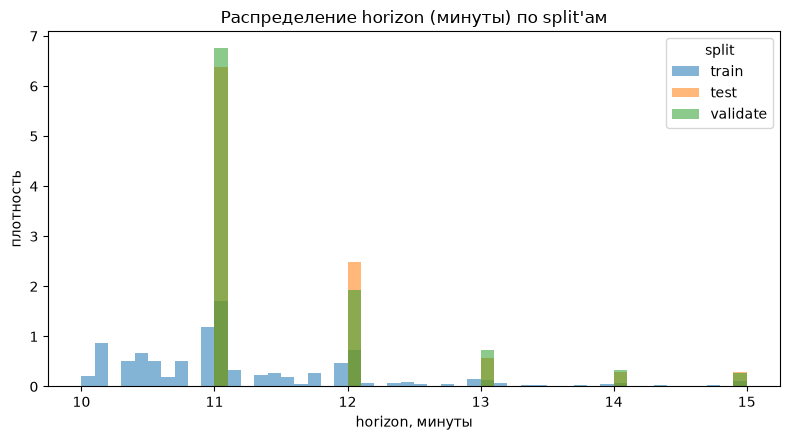

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(10, 15, 51)
for name, color in [("train", "#1f77b4"), ("test", "#ff7f0e"), ("validate", "#2ca02c")]:
    ax.hist(horizon[name], bins=bins, alpha=0.55, label=name, color=color, density=True)
ax.set_title("Распределение horizon (минуты) по split'ам")
ax.set_xlabel("horizon, минуты")
ax.set_ylabel("плотность")
ax.legend(title="split")
fig.tight_layout()
plt.show()

**Наблюдение:** `test` и `validate` используют **только целые** значения
horizon (11–15 минут), тогда как `train` содержит много **дробных** значений
horizon в диапазоне `(10, 15]`. Это систематическое различие между split'ами
по способу построения прогнозных точек (вероятно, разный шаг генерации
точек `T` при разметке train против test/validate). Само по себе это не
нарушает границы целевого окна (`10 < horizon ≤ 15` выполняется всегда), но
является потенциальным domain shift между train и test/validate, который
стоит учитывать при выборе фичей, завязанных на горизонт.

Осторожная интерпретация: мы **не** утверждаем, что это влияет на качество
модели — это лишь наблюдаемое структурное различие, требующее внимания.

**Статус: ДОКАЗАНО ДАННЫМИ** (сам факт распределения); интерпретация его
влияния на моделирование — **ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ**.

## 6. Проверка target integrity (только train/test)

**Вопрос:** действительно ли `target_delay_s = time_fact_begin − time_begin`
для соответствующей schedule-записи (`target_stop_id == tt_action_item_id`,
`tr_id`)?

**Метод:** join `labels` с `schedule` по `(target_stop_id == tt_action_item_id,
tr_id)` со строгой валидацией `validate="one_to_one"` (R5) — merge упадёт с
`MergeError`, если хотя бы одна сторона содержит дублирующийся ключ, — затем
пересчитать задержку и сравнить с `target_delay_s`.

Эта проверка выполняется **только для train/test**, где у нас есть факт
(`time_fact_begin`). Для `validate` она **намеренно не выполняется** — там
`time_fact_begin` не выдан, и попытка получить его была бы той самой
утечкой, которая разбирается в разделе 9.

In [11]:
def check_target_integrity(labels: pd.DataFrame, schedule: pd.DataFrame, name: str) -> pd.DataFrame:
    merged = labels.merge(
        schedule[["tt_action_item_id", "tr_id", "time_begin", "time_fact_begin"]],
        left_on=["target_stop_id", "tr_id"],
        right_on=["tt_action_item_id", "tr_id"],
        how="left",
        validate="one_to_one",  # (R5) падает с MergeError при дублирующемся ключе на любой стороне
    )
    assert len(merged) == len(labels), f"{name}: длина после merge разошлась с исходными labels"

    matched = merged["time_fact_begin"].notna().sum()
    calculated_delay = (merged["time_fact_begin"] - merged["time_begin"]).dt.total_seconds()
    abs_diff = (calculated_delay - merged["target_delay_s"]).abs()
    exact = int((abs_diff < 1e-6).sum())
    print(f"{name}: len(merged)={len(merged)} == len(labels)={len(labels)}  "
          f"matched={matched}/{len(merged)}  exact_match={exact}/{len(merged)}  "
          f"max_abs_diff={abs_diff.max():.6f}")
    assert matched == len(merged), f"{name}: не для всех точек нашлась schedule-запись"
    assert exact == len(merged), f"{name}: расчётная задержка разошлась с target_delay_s"
    return merged


_ = check_target_integrity(labels_train, train_schedule, "train")
_ = check_target_integrity(labels_test, test_schedule, "test")
print()
print("validate='one_to_one' не бросил MergeError — ключи (target_stop_id, tr_id) "
      "действительно уникальны с обеих сторон merge'а.")

train: len(merged)=4434 == len(labels)=4434  matched=4434/4434  exact_match=4434/4434  max_abs_diff=0.000000
test: len(merged)=353 == len(labels)=353  matched=353/353  exact_match=353/353  max_abs_diff=0.000000

validate='one_to_one' не бросил MergeError — ключи (target_stop_id, tr_id) действительно уникальны с обеих сторон merge'а.


**Вывод:** для **100% строк** train (4434/4434) и test (353/353)
`target_delay_s` точно равен `time_fact_begin − time_begin` соответствующей
schedule-записи, максимальное абсолютное расхождение — 0, длина после merge
совпадает с исходной длиной labels, merge прошёл строгую `one_to_one`
валидацию без дублирующихся ключей. Семантика target подтверждена буквально,
а не только по описанию в README.

**Статус: ДОКАЗАНО ДАННЫМИ**

## 7. Split relationships и overlap

**Вопрос:** пересекаются ли `train`/`test`/`validate` по `sample_id` или по
прогнозным точкам `(tr_id, T)`? Это критично: пересечение означало бы утечку
train→test/validate на уровне разметки.

**Метод:** пересечение множеств `sample_id` и `(tr_id, T)` попарно между
всеми тремя split'ами.

In [12]:
def id_overlap(a: pd.DataFrame, b: pd.DataFrame, col: str) -> int:
    return len(set(a[col]) & set(b[col]))


def point_overlap(a: pd.DataFrame, b: pd.DataFrame) -> int:
    return len(set(zip(a["tr_id"], a["T"])) & set(zip(b["tr_id"], b["T"])))


pairs = [("train", labels_train, "test", labels_test),
         ("train", labels_train, "validate", validate_points),
         ("test", labels_test, "validate", validate_points)]

for name_a, df_a, name_b, df_b in pairs:
    so = id_overlap(df_a, df_b, "sample_id")
    po = point_overlap(df_a, df_b)
    print(f"{name_a}/{name_b}: sample_id overlap={so}  (tr_id,T) overlap={po}")
    assert so == 0 and po == 0, f"Обнаружено пересечение {name_a}/{name_b} — потенциальная утечка разметки!"

print()
print("Пересечений не обнаружено ни по sample_id, ни по (tr_id, T) — split'ы взаимно не пересекаются по разметке.")

train/test: sample_id overlap=0  (tr_id,T) overlap=0
train/validate: sample_id overlap=0  (tr_id,T) overlap=0
test/validate: sample_id overlap=0  (tr_id,T) overlap=0

Пересечений не обнаружено ни по sample_id, ни по (tr_id, T) — split'ы взаимно не пересекаются по разметке.


### 7.1. Cross-split target-action overlap: `(tr_id, target_stop_id)` (micro-fix 3)

Проверка выше (по `sample_id` и по `(tr_id, T)`) не полностью исключает более
тонкий сценарий: что разные split'ы предсказывают **одно и то же плановое
schedule-событие** (`target_stop_id`, он же `tt_action_item_id`, раздел 16)
для одного и того же `tr_id` — просто с другим `T`. Проверяем это напрямую
по ключу `(tr_id, target_stop_id)`. Никакой `time_fact_begin`, никакой
скрытый validate target и никакой `test/schedule.csv`-факт здесь не
используются — только `tr_id`/`target_stop_id` из уже загруженных
`labels_train`/`labels_test`/`validate_points`.

In [13]:
def target_action_keys(df: pd.DataFrame) -> set:
    return set(zip(df["tr_id"], df["target_stop_id"]))


action_pairs = [
    ("train", labels_train, "test", labels_test),
    ("train", labels_train, "validate", validate_points),
    ("test", labels_test, "validate", validate_points),
]

action_overlap_rows = []
for name_a, df_a, name_b, df_b in action_pairs:
    overlap = target_action_keys(df_a) & target_action_keys(df_b)
    action_overlap_rows.append({"pair": f"{name_a}/{name_b}", "overlap_count": len(overlap)})
    print(f"{name_a}/{name_b}: (tr_id,target_stop_id) overlap={len(overlap)}")

action_overlap_df = pd.DataFrame(action_overlap_rows).set_index("pair")
action_overlap_df

train/test: (tr_id,target_stop_id) overlap=0
train/validate: (tr_id,target_stop_id) overlap=0
test/validate: (tr_id,target_stop_id) overlap=0


,overlap_count
pair,
train/test,0
train/validate,0
test/validate,0


**Вывод (micro-fix 3, фактический результат этого запуска):** пересечений по
`(tr_id, target_stop_id)` между train/test, train/validate и test/validate
**не обнаружено** (0/0/0 — см. таблицу выше). Ни одна прогнозная точка
любого split'а не нацелена на то же самое плановое schedule-событие, что и
точка другого split'а. Это дополнительное (к проверке по
`sample_id`/`(tr_id, T)` выше) структурное доказательство отсутствия прямого
label duplication между prediction points разных split'ов — по более узкому
и более осмысленному с точки зрения предметной области ключу, чем просто
временная точка.

**Статус: ДОКАЗАНО ДАННЫМИ**

**Терминологическая заметка (R2, детально в разделе 8):** ниже мы делим
`tr_id` из `train` на "реальную" группу (13 ID, совпадающих с `test`) и
"остальную" группу (26 ID, диапазон `9000000–9000025`). README организаторов
подтверждает **факт наличия synthetic ТС в train**, но не называет конкретный
диапазон ID. Поэтому вторую группу мы называем **train-only /
synthetic-candidate** — структурно она видна только в train, но её точное
происхождение (synthetic-генератор) официально не подтверждено на уровне ID.

In [14]:
CANDIDATE_MIN, CANDIDATE_MAX = 9_000_000, 9_000_025

is_candidate_train = labels_train["tr_id"].between(CANDIDATE_MIN, CANDIDATE_MAX)
real_train_ids = sorted(labels_train.loc[~is_candidate_train, "tr_id"].unique())
candidate_train_ids = sorted(labels_train.loc[is_candidate_train, "tr_id"].unique())

test_ids = sorted(labels_test["tr_id"].unique())
validate_point_ids = sorted(validate_points["tr_id"].unique())
validate_schedule_ids = sorted(validate_schedule_plan["tr_id"].unique())

print("train, группа A ('real', 13 ID, см. раздел 8):", real_train_ids)
print("train, группа B ('train-only / synthetic-candidate'): диапазон",
      candidate_train_ids[0], "…", candidate_train_ids[-1], f"({len(candidate_train_ids)} шт.)")
print()
print("официальный test, tr_id:", test_ids)
print("группа A (train) == официальный test tr_id:", set(real_train_ids) == set(test_ids))
print()
print("validate/schedule_plan.csv, tr_id (13 шт.):", validate_schedule_ids)
print("validate/points.csv, tr_id (сколько из 13 реально представлено прогнозными точками):",
      validate_point_ids, f"— {len(validate_point_ids)} из {len(validate_schedule_ids)}")

vehicle_counts = pd.DataFrame({
    "split": ["train — группа A (13 real)", "train — группа B (26 train-only/candidate)",
              "test (labels)", "validate (points)", "validate (schedule_plan)"],
    "n_vehicles": [
        len(real_train_ids), len(candidate_train_ids),
        labels_test["tr_id"].nunique(), validate_points["tr_id"].nunique(),
        validate_schedule_plan["tr_id"].nunique(),
    ],
})
vehicle_counts

train, группа A ('real', 13 ID, см. раздел 8): [np.int64(122048), np.int64(122613), np.int64(122658), np.int64(129964), np.int64(130072), np.int64(130238), np.int64(131672), np.int64(132430), np.int64(133300), np.int64(133957), np.int64(134040), np.int64(134494), np.int64(135081)]
train, группа B ('train-only / synthetic-candidate'): диапазон 9000000 … 9000025 (26 шт.)

официальный test, tr_id: [np.int64(122048), np.int64(122613), np.int64(122658), np.int64(129964), np.int64(130072), np.int64(130238), np.int64(131672), np.int64(132430), np.int64(133300), np.int64(133957), np.int64(134040), np.int64(134494), np.int64(135081)]
группа A (train) == официальный test tr_id: True

validate/schedule_plan.csv, tr_id (13 шт.): [np.int64(122048), np.int64(122613), np.int64(122658), np.int64(129964), np.int64(130072), np.int64(130238), np.int64(131672), np.int64(132430), np.int64(133300), np.int64(133957), np.int64(134040), np.int64(134494), np.int64(135081)]
validate/points.csv, tr_id (сколько из

,split,n_vehicles
0,train — группа A (13 real),13
1,train — группа B (26 train-only/candidate),26
2,test (labels),13
3,validate (points),11
4,validate (schedule_plan),13


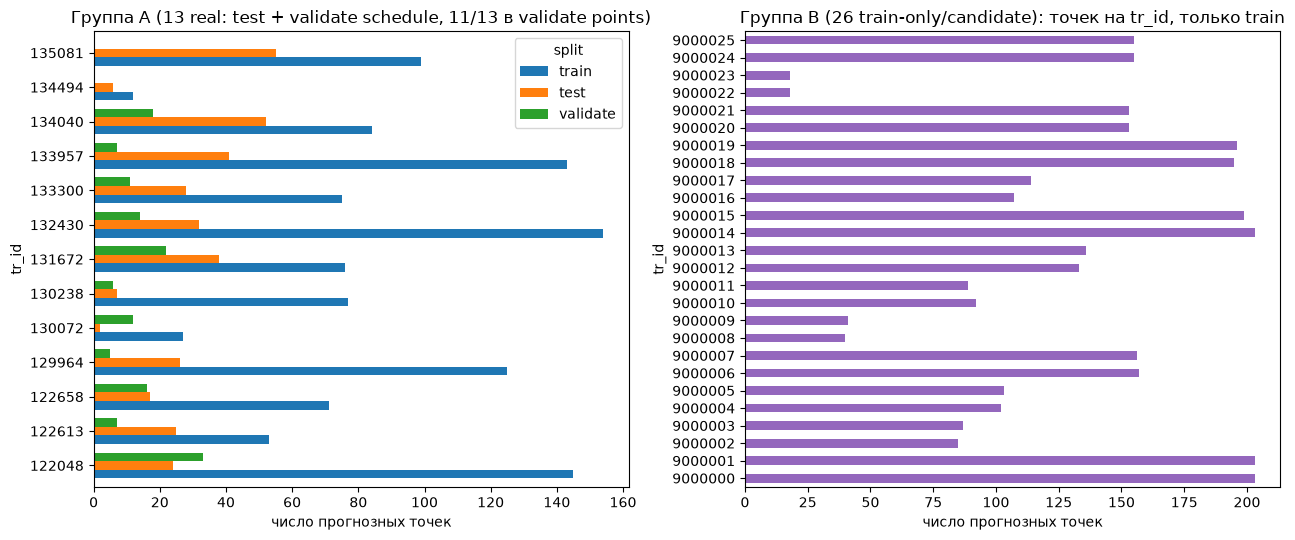

In [15]:
# (R9.1) Читаемая визуализация: раздельные подграфики для группы A (13 real,
# сопоставимо со всеми split'ами) и группы B (26 train-only/candidate, только train).
points_per_vehicle_real = pd.concat([
    labels_train[~is_candidate_train].groupby("tr_id").size().rename("train"),
    labels_test.groupby("tr_id").size().rename("test"),
    validate_points.groupby("tr_id").size().rename("validate"),
], axis=1)

points_per_vehicle_candidate = (
    labels_train[is_candidate_train].groupby("tr_id").size().rename("train-only/candidate").sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

points_per_vehicle_real.plot(kind="barh", ax=axes[0], width=0.75)
axes[0].set_title("Группа A (13 real: test + validate schedule, 11/13 в validate points)")
axes[0].set_xlabel("число прогнозных точек")
axes[0].set_ylabel("tr_id")
axes[0].legend(title="split")

points_per_vehicle_candidate.plot(kind="barh", ax=axes[1], color="#9467bd")
axes[1].set_title("Группа B (26 train-only/candidate): точек на tr_id, только train")
axes[1].set_xlabel("число прогнозных точек")
axes[1].set_ylabel("tr_id")

fig.tight_layout()
plt.show()

**Вывод (точная формулировка, R10):** пересечений `(tr_id, T)`/`sample_id`
между split'ами нет — структурной утечки на уровне самих прогнозных точек
нет. Официальный `test` содержит **13** `tr_id` (группа A). `validate/schedule_plan.csv`
содержит **те же 13** `tr_id`, но **прогнозные точки `validate/points.csv`
представлены только для 11 из них** — то есть не для всех 13 официальных
"реальных" машин фактически создана точка прогноза в validate. Группа B
(train-only/candidate, 26 ID) присутствует **только** в train.

**Статус: ДОКАЗАНО ДАННЫМИ**

## 8. Состав train: real vs train-only/synthetic-candidate группа (R2)

**Вопрос:** организаторы заявляют, что в `train` добавлены синтетические ТС
"для объёма". README **не называет** конкретный диапазон `tr_id` — значит,
маркировать `tr_id ∈ [9000000, 9000025]` как "synthetic" на основании одной
только структуры ID было бы **недоказанным утверждением**, выданным за факт.

**Что мы делаем вместо этого:** проверяем README и `docs/` датасета на
предмет явного указания диапазона ID.

In [16]:
readme_text = (DATASET_ROOT / "README.md").read_text(encoding="utf-8")
docs_text = (DATASET_ROOT / "docs" / "Emulator-and-Telematic-Packets-Specification.md").read_text(encoding="utf-8")

for needle in ["synthetic", "синтетич", "9000000", "9_000_000"]:
    in_readme = needle.lower() in readme_text.lower()
    in_docs = needle.lower() in docs_text.lower()
    print(f"{needle!r:20s}  README: {in_readme}   docs/Emulator-spec: {in_docs}")

'synthetic'           README: False   docs/Emulator-spec: False
'синтетич'            README: True   docs/Emulator-spec: True
'9000000'             README: False   docs/Emulator-spec: False
'9_000_000'           README: False   docs/Emulator-spec: False


**Результат:** README упоминает `синтетические` только один раз — фраза "В
`train` добавлены синтетические ТС (для объёма); `test`/`validate` —
полностью реальные" — **без привязки к конкретному диапазону ID**.
В `docs/Emulator-and-Telematic-Packets-Specification.md` слово встречается
один раз, но в не связанном контексте (синтетическая навигация при
отсутствии конфига устройства в эмуляторе, не про ID транспортных средств).

**Вывод: официального explicit-указания диапазона ID нет.** Это Вариант B из
задания. Поэтому вместо "synthetic" мы используем термин **train-only /
synthetic-candidate** и доказываем принадлежность к группе только
структурно (раздел 7): 26 ID из диапазона `9000000–9000025` присутствуют
исключительно в train (0 — в test, 0 — в validate), тогда как остальные 13 ID
из train — это ровно официальный `test`-набор `tr_id`.

**Формулировка для дальнейшего использования:**
> "Эта группа (26 ID, диапазон `9000000–9000025`) согласуется с описанной
> организаторами synthetic-частью train, но точное соответствие ID-range
> synthetic-генератору официально не подтверждено доступной документацией."

**Статус: ДОКАЗАНО ДАННЫМИ** (структурная обособленность группы);
**НЕ ПОДТВЕРЖДЕНО** (что это именно те самые "синтетические ТС", о которых
пишет README — правдоподобно, но не доказано документацией).

In [17]:
real_train = labels_train[~is_candidate_train].copy()
candidate_train = labels_train[is_candidate_train].copy()

print(f"группа A (real: test + validate schedule, 11/13 в validate points): {len(real_train)} строк, {real_train['tr_id'].nunique()} ТС")
print(f"группа B (train-only/synthetic-candidate): {len(candidate_train)} строк, {candidate_train['tr_id'].nunique()} ТС")
print(f"доля группы B в labels_train: {len(candidate_train) / len(labels_train):.1%}")

assert len(real_train) + len(candidate_train) == len(labels_train)

группа A (real: test + validate schedule, 11/13 в validate points): 1141 строк, 13 ТС
группа B (train-only/synthetic-candidate): 3293 строк, 26 ТС
доля группы B в labels_train: 74.3%


In [18]:
def group_summary(df: pd.DataFrame, name: str) -> dict:
    residual = df["target_delay_s"] - df["cur_dev_s"]
    return {
        "group": name,
        "n": len(df),
        "target_mean": df["target_delay_s"].mean(),
        "target_median": df["target_delay_s"].median(),
        "target_std": df["target_delay_s"].std(),
        "cur_dev_MAE": (df["target_delay_s"] - df["cur_dev_s"]).abs().mean(),
        "residual_std": residual.std(),
    }


composition_summary = pd.DataFrame([
    group_summary(real_train, "A: real (train)"),
    group_summary(candidate_train, "B: train-only/candidate (train)"),
    group_summary(labels_test, "test (официально все реальные)"),
]).set_index("group").round(3)
composition_summary

,n,target_mean,target_median,target_std,cur_dev_MAE,residual_std
group,,,,,,
A: real (train),1141,44.851,18.0,124.388,86.838,123.997
B: train-only/candidate (train),3293,50.289,26.0,133.500,95.179,132.330
test (официально все реальные),353,55.654,26.0,135.459,93.360,128.111


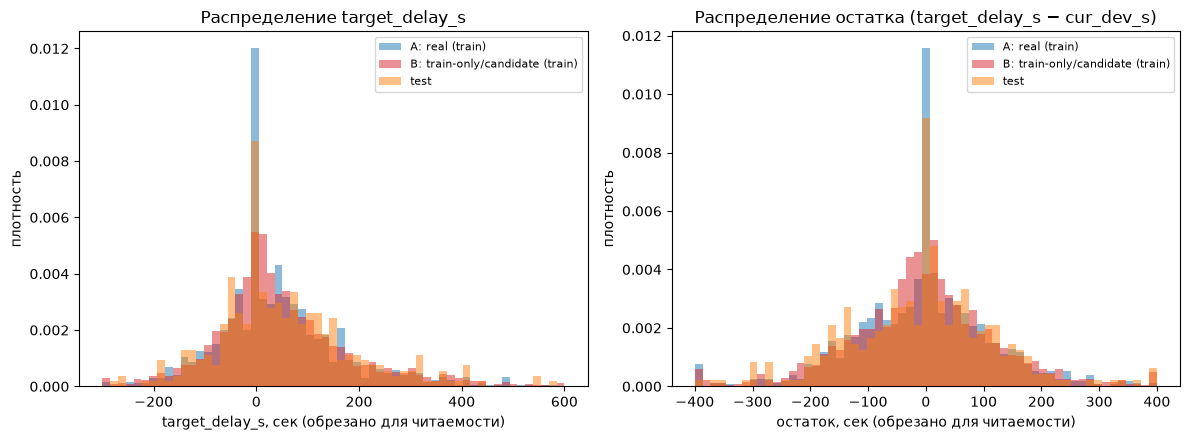

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

groups = [("A: real (train)", real_train, "#1f77b4"),
          ("B: train-only/candidate (train)", candidate_train, "#d62728"),
          ("test", labels_test, "#ff7f0e")]

bins_target = np.linspace(-300, 600, 60)
for name, df, color in groups:
    axes[0].hist(df["target_delay_s"].clip(-300, 600), bins=bins_target, alpha=0.5,
                 label=name, color=color, density=True)
axes[0].set_title("Распределение target_delay_s")
axes[0].set_xlabel("target_delay_s, сек (обрезано для читаемости)")
axes[0].set_ylabel("плотность")
axes[0].legend(fontsize=8)

bins_resid = np.linspace(-400, 400, 60)
for name, df, color in groups:
    residual = (df["target_delay_s"] - df["cur_dev_s"]).clip(-400, 400)
    axes[1].hist(residual, bins=bins_resid, alpha=0.5, label=name, color=color, density=True)
axes[1].set_title("Распределение остатка (target_delay_s − cur_dev_s)")
axes[1].set_xlabel("остаток, сек (обрезано для читаемости)")
axes[1].set_ylabel("плотность")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

**Вывод:** группа B (train-only/synthetic-candidate) составляет **≈74.3%**
строк `labels_train` (3293 из 4434 — не "74.3% synthetic", а именно "74.3%
train labels относятся к train-only/synthetic-candidate группе"). У группы B
заметно больше точек на машину, чем у группы A.

Распределения `target_delay_s` и остатка у группы B **систематически
сдвинуты** относительно группы A: выше среднее, медиана и std, и
`cur_dev_s`-baseline MAE тоже выше (95.18 против 86.84). Test (полностью
официально реальный) по этим метрикам ближе к группе A, чем к группе B.

Мы **намеренно не** делаем вывод, что группа B "плохая" или "нерелевантна" —
у нас нет оснований дать такую оценку без обучения модели. Корректный вывод:
**группа B — это отдельный по статистике поддомен данных, доминирующий по
объёму train**, и её реальное происхождение (synthetic-генератор или что-то
иное) официально не подтверждено. Эффект обучения на ней нужно проверять
экспериментально, оценивая исключительно на `labels_test`.

**Статус: ДОКАЗАНО ДАННЫМИ** (состав и статистика); происхождение группы —
**НЕ ПОДТВЕРЖДЕНО** официальной документацией; эффект на модель —
**ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ**.

## 9. КРИТИЧЕСКИЙ leakage audit

Это один из главных разделов этого notebook. Здесь мы проверяем, не выдаёт ли
структура раздачи файлов способ восстановить скрытый target `validate` в
обход официального протокола.

### 9.1. `test/traffic.csv` == `validate/traffic.csv`?

**Метод:** побайтовое сравнение через SHA-256 (уже посчитан в разделе 1.1).

In [20]:
sha_test = fingerprint_df.set_index("relative_path").loc["test/traffic.csv", "sha256"]
sha_val = fingerprint_df.set_index("relative_path").loc["validate/traffic.csv", "sha256"]
print("SHA-256 test/traffic.csv:    ", sha_test)
print("SHA-256 validate/traffic.csv:", sha_val)
byte_identical = sha_test == sha_val
print("byte-identical:", byte_identical)
assert byte_identical, "test/traffic.csv и validate/traffic.csv НЕ идентичны — пересчитать интерпретацию раздела 9"

SHA-256 test/traffic.csv:     3c74bb9d3cc5e076a2e7f89de7e78fb103c350757d16c9d629de651ee09bf517
SHA-256 validate/traffic.csv: 3c74bb9d3cc5e076a2e7f89de7e78fb103c350757d16c9d629de651ee09bf517
byte-identical: True


### 9.2. `test/schedule.csv` (без `time_fact_begin`) == `validate/schedule_plan.csv`?

**Метод:** взять `test/schedule.csv`, убрать столбец `time_fact_begin`,
сравнить построчно и по колонкам с `validate/schedule_plan.csv`.

In [21]:
test_schedule_sans_fact = test_schedule.drop(columns=["time_fact_begin"]).reset_index(drop=True)
validate_plan_reset = validate_schedule_plan.reset_index(drop=True)

same_columns = list(test_schedule_sans_fact.columns) == list(validate_plan_reset.columns)
same_shape = test_schedule_sans_fact.shape == validate_plan_reset.shape
exact_equal = test_schedule_sans_fact.equals(validate_plan_reset)

print("одинаковые колонки:", same_columns)
print("одинаковая форма:  ", same_shape, test_schedule_sans_fact.shape, validate_plan_reset.shape)
print("построчно идентичны:", exact_equal)
assert same_columns and same_shape and exact_equal, "test/schedule (без факта) и validate/schedule_plan РАСХОДЯТСЯ"

одинаковые колонки: True
одинаковая форма:   True (5558, 7) (5558, 7)
построчно идентичны: True


### 9.3. Присутствуют ли `validate`-таргеты (со своим фактом) в `test/schedule.csv`?

Для этой конкретной ячейки мы читаем `test/schedule.csv` **заново**, явно
через `usecols=["tt_action_item_id", "tr_id"]` — то есть в **эту переменную**
`time_fact_begin` не попадает вообще. (Обратите внимание: сам файл
`test_schedule`, загруженный в разделе 3 для нужд раздела 6, **уже содержит**
`time_fact_begin` в памяти kernel'а — мы не притворяемся, что это не так; см.
предупреждение в начале notebook и точную формулировку инварианта в 9.4.)

In [22]:
test_schedule_keys_only = pd.read_csv(
    DATASET_ROOT / "test/schedule.csv", usecols=["tt_action_item_id", "tr_id"]
)
assert "time_fact_begin" not in test_schedule_keys_only.columns

validate_target_keys = set(zip(validate_points["target_stop_id"], validate_points["tr_id"]))
test_schedule_keys = set(zip(test_schedule_keys_only["tt_action_item_id"], test_schedule_keys_only["tr_id"]))

present = validate_target_keys & test_schedule_keys
print(f"validate (target_stop_id, tr_id), присутствующие в test/schedule.csv: "
      f"{len(present)}/{len(validate_target_keys)}")

validate (target_stop_id, tr_id), присутствующие в test/schedule.csv: 151/151


### 9.4. Вывод и точная формулировка invariant (R1)

Так как в разделе 6 доказано, что для train/test
`target_delay_s = time_fact_begin − time_begin` **точно**, а раздел 9.3
показывает, что **все 151/151** `(target_stop_id, tr_id)` из
`validate/points.csv` присутствуют как schedule-actions в `test/schedule.csv`
— файле, который **содержит `time_fact_begin`** для этих же самых
schedule-actions, и который этот notebook **уже загрузил целиком** в разделе 3
для законных нужд раздела 6, — структура раздачи создаёт возможность
восстановить скрытый target `validate`, объединив `validate/points.csv` с
`test/schedule.csv` по `(target_stop_id == tt_action_item_id, tr_id)` и
посчитав `time_fact_begin − time_begin`.

**Эта возможность является утечкой и запрещена к использованию.**

**Точная формулировка того, что мы гарантируем** (важно не переусиливать
формулировку — `test/schedule.csv` со своим фактом объективно находится в
памяти kernel'а, и это нормально для train/test-анализа):

> Hidden validate target нигде в этом notebook **не вычислялся, не
> восстанавливался, не join'ился с `validate/points.csv`, не выводился и не
> использовался** для анализа или предсказания. `test/schedule.csv` как
> официальный test-артефакт загружался и использовался для train/test
> target-integrity анализа (раздел 6), но его факт (`time_fact_begin`)
> **ни разу не связывался** с `validate/points.csv` или
> `validate/schedule_plan.csv` ни в одной ячейке этого notebook.

Мы **не выполняем** запрещённое вычисление здесь ни в каком виде: не строим
join `validate` с `time_fact_begin`, не печатаем `time_fact_begin` рядом с
`validate`-точками, не считаем MAE на `validate`, не создаём `submission.csv`
на основе этой утечки. Это проверяется явно в финальной ячейке notebook.

**Зафиксированный invariant допустимых источников для validate:**

| Источник | Статус |
|---|---|
| `validate/schedule_plan.csv` | разрешено |
| `validate/traffic.csv` (`event_time ≤ T`) | разрешено |
| `validate/points.csv` (`T`, `cur_dev_s`, `target_stop_id`, `target_time_begin`) | разрешено |
| `test/schedule.csv` целиком, для train/test-анализа (раздел 6) | разрешено (не про validate) |
| `test/schedule.csv` → колонка `time_fact_begin` **в связке с `validate`** | **ЗАПРЕЩЕНО ИЗ-ЗА УТЕЧКИ** |

**Статус: ДОКАЗАНО ДАННЫМИ** (наличие структурной возможности утечки);
**использование этой возможности — ЗАПРЕЩЕНО ИЗ-ЗА УТЕЧКИ** и нигде в этом
notebook не выполняется (проверено явно, см. финальную ячейку).

## 10. Связь train/test/validate telemetry

**Вопрос:** насколько независимы периоды телеметрии `train`/`test`/`validate`?
Мы уже знаем (раздел 9.1), что `test/traffic.csv` и `validate/traffic.csv`
байт-в-байт идентичны. А содержится ли telemetry `test` внутри `train`?

**Метод:** сравнить временны́е диапазоны `event_time`; проверить, сколько
строк `test/traffic.csv` присутствует в `train/traffic.csv` по ключу
`(packet_id, tr_id, event_time)`.

In [23]:
for name, df in [("train", train_traffic), ("test", test_traffic), ("validate", validate_traffic)]:
    print(f"{name} event_time: {df['event_time'].min()}  ->  {df['event_time'].max()}")

train event_time: 2026-01-05 23:46:15.880133799  ->  2026-01-07 00:25:58.268893882
test event_time: 2026-01-06 00:00:02  ->  2026-01-06 23:59:59
validate event_time: 2026-01-06 00:00:02  ->  2026-01-06 23:59:59


In [24]:
key_cols = ["packet_id", "tr_id", "event_time"]
merged_presence = test_traffic[key_cols].merge(
    train_traffic[key_cols], on=key_cols, how="left", indicator=True
)
present_in_train = int((merged_presence["_merge"] == "both").sum())
print(f"test telemetry rows, присутствующие в train (по packet_id,tr_id,event_time): "
      f"{present_in_train}/{len(test_traffic)}")

test telemetry rows, присутствующие в train (по packet_id,tr_id,event_time): 105945/105945


**Вывод (аккуратная формулировка):** `train` телеметрически **не является**
полностью независимым от `test`/`validate` периодом — временной диапазон
`train` (2026-01-05 23:46 → 2026-01-07 00:26) полностью покрывает 24-часовой
диапазон `test`/`validate` (2026-01-06 00:00 → 23:59), и **все строки** `test`
буквально присутствуют внутри `train/traffic.csv` как подмножество (по
точному совпадению `packet_id`, `tr_id`, `event_time`). `train`, помимо этого
общего с test/validate дня, дополнительно содержит телеметрию за края суток
5 и 7 января и, вероятно, телеметрию train-only/candidate группы (раздел 8).

Мы **не** делаем из этого вывод, что labels/`target_delay_s` train и test
как-то связаны, и **не** строим никаких join'ов между `train`-разметкой и
`test`-телеметрией сверх уже сделанных выше явных проверок пересечения
`sample_id`/`(tr_id,T)` (раздел 7, результат — 0 пересечений). Речь идёт
именно о телеметрии как о сыром временном ряде, а не о разметке. Раздел 15
(temporal-nearness) отдельно исследует, насколько близко по времени точки
`test` и группы A `train` расположены друг к другу для одних и тех же машин.

**Статус: ДОКАЗАНО ДАННЫМИ**

## 11. Target, `cur_dev_s` и baseline evidence

**Вопрос:** насколько полезен официальный baseline-сигнал `cur_dev_s` сам по
себе (без какой-либо модели) для предсказания `target_delay_s`?

**Метод:** посчитать MAE для нескольких тривиальных baseline'ов на train и
test, посмотреть корреляцию `cur_dev_s` с target, посмотреть остаток.

In [25]:
train_target_median = labels_train["target_delay_s"].median()
print("Медиана target_delay_s на train (используется как константный baseline):", train_target_median)


def baseline_report(labels: pd.DataFrame, name: str) -> dict:
    target = labels["target_delay_s"]
    cur_dev = labels["cur_dev_s"]
    residual = target - cur_dev
    return {
        "split": name,
        "MAE_zero": target.abs().mean(),
        "MAE_cur_dev_s": (target - cur_dev).abs().mean(),
        "MAE_train_median": (target - train_target_median).abs().mean(),
        "pearson_cur_dev_target": target.corr(cur_dev),
        "residual_median": residual.median(),
        "residual_std": residual.std(),
    }


baseline_df = pd.DataFrame([
    baseline_report(labels_train, "train"),
    baseline_report(labels_test, "test"),
]).set_index("split").round(4)
baseline_df

Медиана target_delay_s на train (используется как константный baseline): 24.0


,MAE_zero,MAE_cur_dev_s,MAE_train_median,pearson_cur_dev_target,residual_median,residual_std
split,,,,,,
train,97.1685,93.0325,94.3051,0.5108,0.0,130.2247
test,103.3371,93.3598,100.8725,0.5344,0.0,128.1110


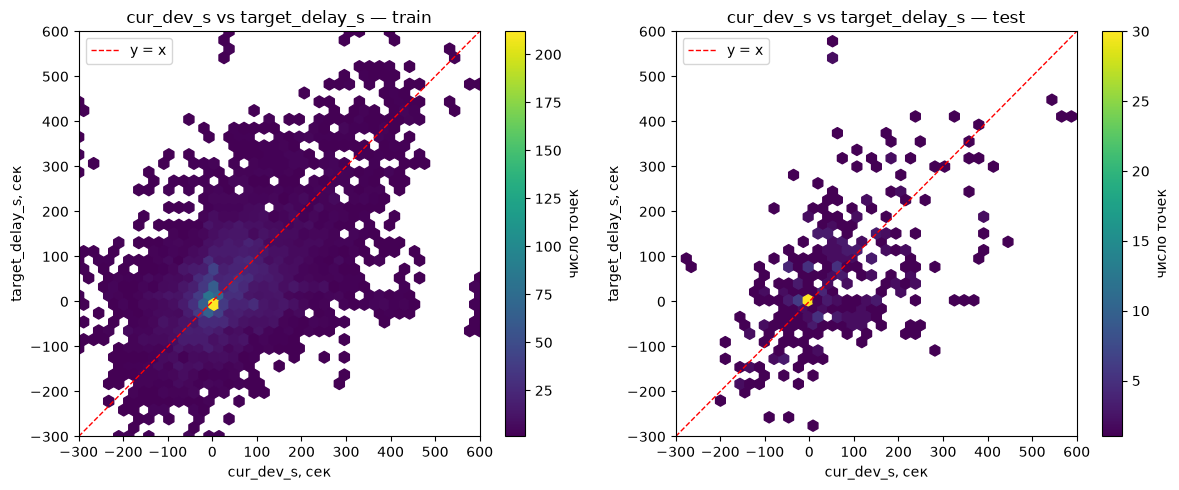

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, labels) in zip(axes, [("train", labels_train), ("test", labels_test)]):
    x = labels["cur_dev_s"].clip(-300, 600)
    y = labels["target_delay_s"].clip(-300, 600)
    hb = ax.hexbin(x, y, gridsize=40, cmap="viridis", mincnt=1)
    lims = [-300, 600]
    ax.plot(lims, lims, color="red", linewidth=1, linestyle="--", label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"cur_dev_s vs target_delay_s — {name}")
    ax.set_xlabel("cur_dev_s, сек")
    ax.set_ylabel("target_delay_s, сек")
    ax.legend(loc="upper left")
    fig.colorbar(hb, ax=ax, label="число точек")

fig.tight_layout()
plt.show()

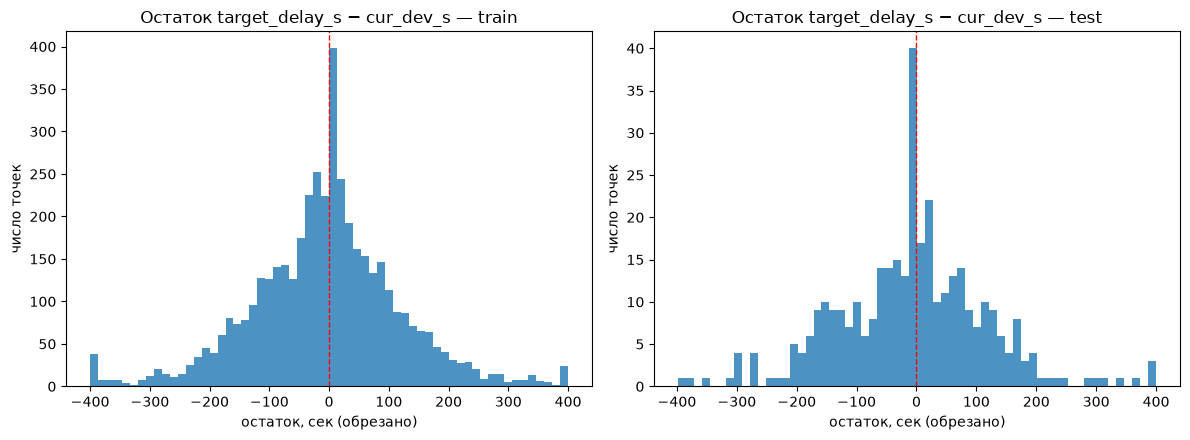

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, labels) in zip(axes, [("train", labels_train), ("test", labels_test)]):
    residual = (labels["target_delay_s"] - labels["cur_dev_s"]).clip(-400, 400)
    ax.hist(residual, bins=60, color="#1f77b4", alpha=0.8)
    ax.axvline(0, color="red", linewidth=1, linestyle="--")
    ax.set_title(f"Остаток target_delay_s − cur_dev_s — {name}")
    ax.set_xlabel("остаток, сек (обрезано)")
    ax.set_ylabel("число точек")

fig.tight_layout()
plt.show()

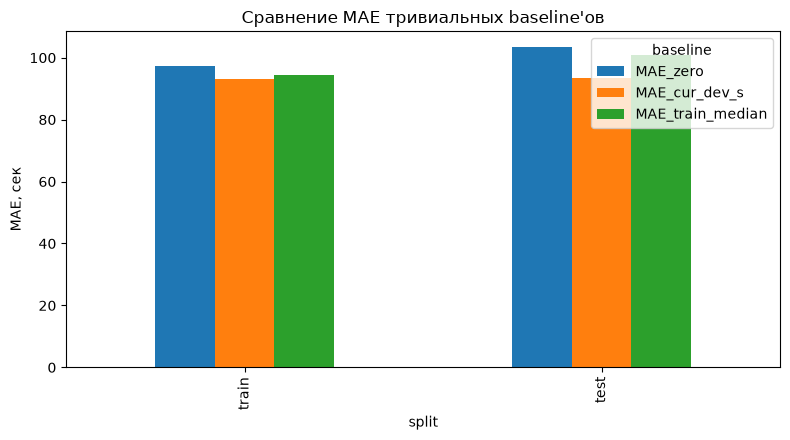

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
baseline_df[["MAE_zero", "MAE_cur_dev_s", "MAE_train_median"]].plot(kind="bar", ax=ax)
ax.set_title("Сравнение MAE тривиальных baseline'ов")
ax.set_ylabel("MAE, сек")
ax.set_xlabel("split")
ax.legend(title="baseline")
fig.tight_layout()
plt.show()

**Вывод:**

- `cur_dev_s`-baseline даёт наименьший MAE среди тривиальных baseline'ов и на
  train (93.03), и на test (93.36) — лучше, чем zero-baseline (97.17 / 103.34)
  и чем константа "медиана train" (94.31 / 100.87).
- Корреляция Пирсона `cur_dev_s` с `target_delay_s` — умеренная (0.511 на
  train, 0.534 на test): сигнал есть, но далеко не полностью объясняет
  target.
- Остаток (`target_delay_s − cur_dev_s`) имеет медиану ровно 0, но большой
  std (≈128–130 сек) — то есть систематического сдвига нет, но разброс
  большой.

**ДОКАЗАНО (R10, точная формулировка):** `cur_dev_s` **не определяет target
полностью** — остаётся значительный residual (std ≈128–130 сек при умеренной
корреляции 0.51–0.53), поэтому есть пространство для проверки дополнительных
predictive features. Мы не утверждаем категорично "необходима модель" —
это разумное следствие остатка такого масштаба, но само по себе наличие
residual не доказывает, что *какая-либо конкретная* модель улучшит результат.

**ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ:** в дополнение к прямой регрессии
`target_delay_s` стоит проверить *residual-формулировку*:

```
delta = target_delay_s - cur_dev_s
final_prediction = cur_dev_s + predicted_delta
```

Мы **не** утверждаем, что residual-формулировка даст лучший результат — это
можно проверить только после обучения модели в обеих постановках.

## 12. `target_class` как вспомогательная характеристика

**Вопрос:** насколько похоже распределение `target_class` (`early`/`ontime`/`late`)
между train и test?

In [29]:
class_props = pd.concat([
    labels_train["target_class"].value_counts(normalize=True).rename("train"),
    labels_test["target_class"].value_counts(normalize=True).rename("test"),
], axis=1).fillna(0) * 100
class_props = class_props.reindex(["early", "ontime", "late"])
class_props.round(2)

,train,test
target_class,,
early,15.31,13.88
ontime,62.18,61.76
late,22.51,24.36


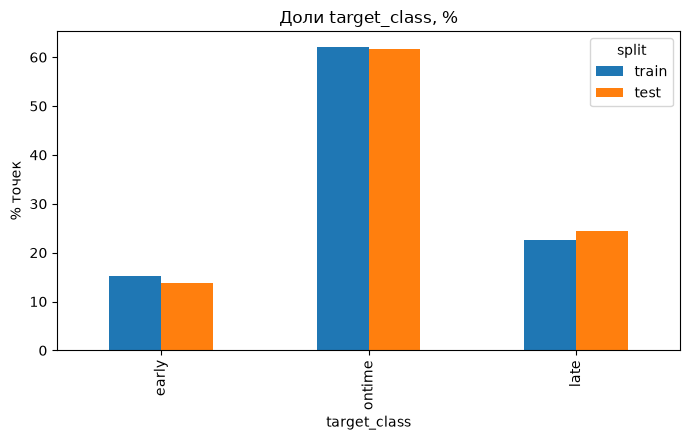

In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))
class_props.plot(kind="bar", ax=ax)
ax.set_title("Доли target_class, %")
ax.set_ylabel("% точек")
ax.set_xlabel("target_class")
ax.legend(title="split")
fig.tight_layout()
plt.show()

**Вывод:** распределение `target_class` в train и test достаточно похоже
(`ontime` ≈62%, `late` ≈22–24%, `early` ≈14–15% в обоих split'ах) — заметного
class shift нет. Тем не менее `target_class` — **справочная** характеристика;
leaderboard-таргет — это `target_delay_s` (регрессия); метрика — MAE по
правилам организаторов (**ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ**, §2), не классификация.

**Статус (распределение target_class): ДОКАЗАНО ДАННЫМИ**

## 13. Telemetry quality audit (обновлено, R3)

**Вопрос:** насколько "чистая" телеметрия? Есть ли пропуски в GPS-полях, и
как соотносится флаг `location_valid` с физическим наличием GPS-данных?

**Метод (R3):** вместо бинарного деления "valid / invalid" вводим явную
**tri-state классификацию качества GPS**, единую для всего notebook:

1. **GPS отсутствует** — `lon`/`lat` пусты (весь GPS-пакет недоступен);
2. **GPS присутствует, но невалиден** — `lon`/`lat` заполнены, но
   `location_valid != True`;
3. **GPS присутствует и валиден** — `lon`/`lat` заполнены **и**
   `location_valid == True`.

На основе этого вводим единую явную маску, которая используется везде далее
в notebook (в т.ч. в разделе 14):

```python
gps_valid = location_valid & lon.notna() & lat.notna()
```

Мы **не удаляем outliers и не придумываем пороги** — только исследуем и
документируем, что видим.

In [31]:
def gps_valid_mask(df: pd.DataFrame) -> pd.Series:
    # Единая явная маска валидного GPS-замера (R3).
    return df["location_valid"].fillna(False) & df["lon"].notna() & df["lat"].notna()


def gps_quality_category(df: pd.DataFrame) -> pd.Series:
    absent = df["lon"].isna() | df["lat"].isna()
    present_invalid = (~absent) & (df["location_valid"] != True)  # noqa: E712
    present_valid = gps_valid_mask(df)
    cat = pd.Series("GPS присутствует и валиден", index=df.index, dtype="object")
    cat[present_invalid] = "GPS присутствует, но невалиден"
    cat[absent] = "GPS отсутствует"
    assert (present_valid == (cat == "GPS присутствует и валиден")).all()
    return cat


gps_cols = ["gps_time", "lon", "lat", "alt", "speed", "heading"]
missing_ratio = train_traffic[gps_cols].isna().mean().rename("missing_ratio")
missing_ratio.to_frame().round(4)

,missing_ratio
gps_time,0.0573
lon,0.0573
lat,0.0573
alt,0.0573
speed,0.0573
heading,0.0573


In [32]:
# (micro-fix 4) Явное доказательство, что gps_valid численно совпадает с
# простым location_valid.fillna(False) на текущем dataset snapshot — а не
# просто "случайно похожие counts", как это выглядело до явной проверки.
gps_equivalence_rows = []
for name, df in [("train", train_traffic), ("test", test_traffic), ("validate", validate_traffic)]:
    simple = df["location_valid"].fillna(False)
    strict = df["location_valid"].fillna(False) & df["lon"].notna() & df["lat"].notna()
    mismatches = int((simple != strict).sum())
    gps_equivalence_rows.append({
        "split": name,
        "rows": len(df),
        "mismatches": mismatches,
        "all_equal": bool(strict.equals(simple)),
    })

gps_equivalence_df = pd.DataFrame(gps_equivalence_rows).set_index("split")
gps_equivalence_df

,rows,mismatches,all_equal
split,,,
train,287849,0,True
test,105945,0,True
validate,105945,0,True


**Вывод (micro-fix 4, доказано, не предположено):** на текущем snapshot
dataset'а `strict` (`location_valid.fillna(False) & lon.notna() & lat.notna()`)
и `simple` (`location_valid.fillna(False)`) дают **0 расхождений** на всех
трёх split'ах (`train`/`test`/`validate`) — см. таблицу выше. Это прямое
доказательство эквивалентности, а не совпадение по построению агрегатов.

Несмотря на эту эквивалентность **на данном снапшоте**, в Feature Contract
(раздел 18) и во всех вычислениях этого notebook продолжает использоваться
именно строгое определение `location_valid & lon.notna() & lat.notna()` — оно
не упрощается обратно до одного `location_valid`, потому что нет гарантии,
что эта эквивалентность сохранится на будущих обновлениях датасета: строгое
определение остаётся корректным в обоих случаях, а упрощённое — нет.

**Статус: ДОКАЗАНО ДАННЫМИ**

In [33]:
gps_masks = {c: train_traffic[c].isna() for c in gps_cols}
base_mask = gps_masks["lon"]
same_mask_everywhere = all((gps_masks[c] == base_mask).all() for c in gps_cols)
print("Все GPS-related колонки пропущены синхронно (одна и та же маска):", same_mask_everywhere)

print()
print("device_event_id, уникальные значения:", sorted(train_traffic["device_event_id"].unique()))
print("location_valid value_counts:")
print(train_traffic["location_valid"].value_counts(dropna=False))

lon_neg_zero = ((train_traffic["lon"] == 0) & np.signbit(train_traffic["lon"].fillna(1.0))).sum()
print()
print("Число строк с lon == -0.0:", int(lon_neg_zero))
print("speed max (км/ч):", train_traffic["speed"].max())
print("alt max:", train_traffic["alt"].max())

Все GPS-related колонки пропущены синхронно (одна и та же маска): True

device_event_id, уникальные значения: [np.int64(0)]
location_valid value_counts:
location_valid
True     243974
False     43875
Name: count, dtype: Int64

Число строк с lon == -0.0: 4426
speed max (км/ч): 368.0
alt max: 65505.0


In [34]:
gps_quality_table = pd.DataFrame({
    name: gps_quality_category(df).value_counts()
    for name, df in [("train", train_traffic), ("test", test_traffic), ("validate", validate_traffic)]
}).fillna(0).astype(int)
gps_quality_table = gps_quality_table.reindex([
    "GPS отсутствует", "GPS присутствует, но невалиден", "GPS присутствует и валиден",
])
gps_quality_pct = (gps_quality_table / gps_quality_table.sum() * 100).round(2)
print("Абсолютные числа строк телеметрии по категории качества GPS:")
display(gps_quality_table)
print()
print("Доли, %:")
gps_quality_pct

Абсолютные числа строк телеметрии по категории качества GPS:


,train,test,validate
GPS отсутствует,16499,6547,6547
"GPS присутствует, но невалиден",27376,10302,10302
GPS присутствует и валиден,243974,89096,89096



Доли, %:


,train,test,validate
GPS отсутствует,5.73,6.18,6.18
"GPS присутствует, но невалиден",9.51,9.72,9.72
GPS присутствует и валиден,84.76,84.10,84.10


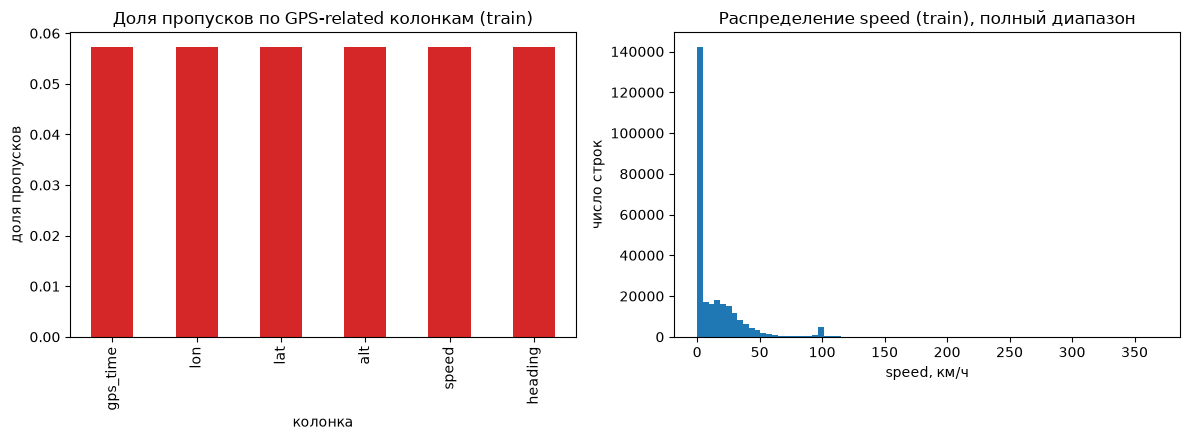

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

missing_ratio.plot(kind="bar", ax=axes[0], color="#d62728")
axes[0].set_title("Доля пропусков по GPS-related колонкам (train)")
axes[0].set_ylabel("доля пропусков")
axes[0].set_xlabel("колонка")

axes[1].hist(train_traffic["speed"].dropna(), bins=80, color="#1f77b4")
axes[1].set_title("Распределение speed (train), полный диапазон")
axes[1].set_xlabel("speed, км/ч")
axes[1].set_ylabel("число строк")

fig.tight_layout()
plt.show()

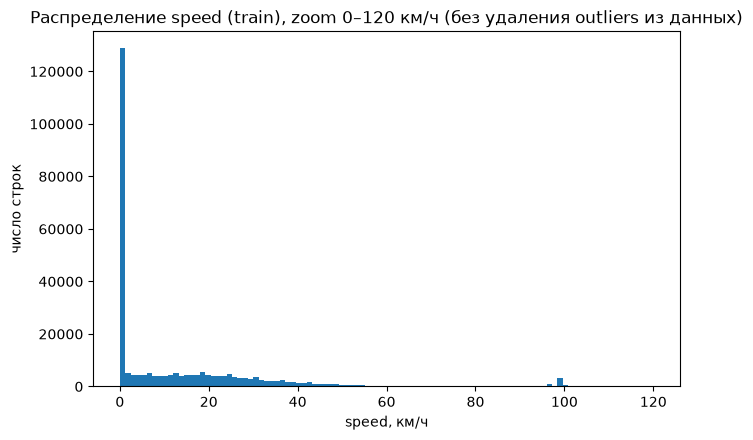

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(train_traffic["speed"].dropna(), bins=100, range=(0, 120), color="#1f77b4")
ax.set_title("Распределение speed (train), zoom 0–120 км/ч (без удаления outliers из данных)")
ax.set_xlabel("speed, км/ч")
ax.set_ylabel("число строк")
fig.tight_layout()
plt.show()

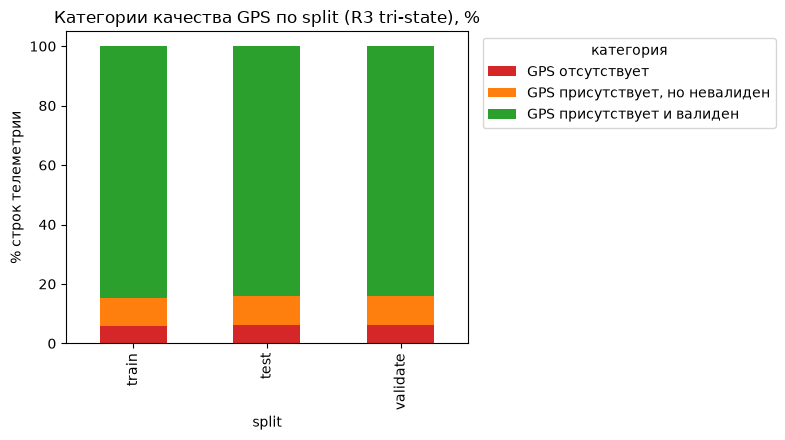

In [37]:
fig, ax = plt.subplots(figsize=(8, 4.5))
gps_quality_pct.T.plot(kind="bar", stacked=True, ax=ax,
                        color=["#d62728", "#ff7f0e", "#2ca02c"])
ax.set_title("Категории качества GPS по split (R3 tri-state), %")
ax.set_ylabel("% строк телеметрии")
ax.set_xlabel("split")
ax.legend(title="категория", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

**Вывод:**

- Все шесть GPS-related колонок (`gps_time`, `lon`, `lat`, `alt`, `speed`,
  `heading`) пропущены **синхронно** — это одна и та же маска missing на
  train, то есть отсутствие GPS — это состояние "весь GPS-пакет
  недоступен", а не случайные пропуски отдельных полей.
- `device_event_id` — константа (`0`) на всём train; как стабильный
  идентификатор события использоваться не может.
- Экстремумы реальны и присутствуют в сырых данных: `speed` до 368 км/ч,
  `alt` до 65505 (вероятно, sentinel-значение датчика, а не реальная
  высота), `lon`/`lat` иногда равны `-0.0`.
- **Tri-state разбиение (R3)** показывает одинаковую структуру на всех трёх
  split'ах: заметная доля "GPS присутствует, но невалиден" — то есть
  `location_valid == False` **не означает** отсутствие GPS-значений;
  наоборот, среди строк с непустыми координатами `location_valid == False`
  встречается чаще, чем можно было бы ожидать из наивного предположения
  "нет координат ⇒ невалидно". Ровно 0 строк одновременно "GPS отсутствует"
  и "valid" — координата не может считаться валидной при отсутствии данных
  (это гарантировано конструкцией маски `gps_valid`, а не отдельно
  проверяемый факт).

**Вывод:** доступность GPS должна моделироваться как явное состояние
качества данных (три категории выше), а не просто через
median-imputation координат — простая импутация скрыла бы содержательное
различие между "нет данных" и "есть данные, но им нельзя доверять".

**Статус: ДОКАЗАНО ДАННЫМИ**

## 14. Feature-feasibility audit: только `event_time ≤ T` (обновлено, R3/R9.2)

**Вопрос:** насколько практически применимы rolling-window признаки
(1/3/5/10/15 минут) и "последнее известное состояние", если строго соблюдать
anti-leakage правило `event_time ≤ T`?

**Метод:** для каждой прогнозной точки `(tr_id, T)` в **REAL TRAIN**, **TEST**
и **VALIDATE** взять телеметрию только с `event_time ≤ T` и посчитать: есть ли
история вообще, задержку (lag) последнего пакета/последнего *валидного* GPS
относительно `T` (используя единую маску `gps_valid` из раздела 13, а не
голый `location_valid`), число строк в скользящих окнах, число валидных
GPS-точек в окнах, число строк с непустым `speed`.

train-only/synthetic-candidate группа (раздел 8) в этот аудит намеренно не
включена (аудит — про реалистичность признаков для реального ТС, а не про
эту группу).

In [38]:
WINDOWS_ROWS = [1, 3, 5, 10, 15]
WINDOWS_GPS = [5, 10, 15]


def point_in_time_audit(points_df: pd.DataFrame, traffic_df: pd.DataFrame) -> pd.DataFrame:
    traffic_sorted = traffic_df.sort_values(["tr_id", "event_time"]).copy()
    traffic_sorted["_gps_valid"] = gps_valid_mask(traffic_sorted)
    grouped = {tr_id: g for tr_id, g in traffic_sorted.groupby("tr_id", sort=False)}

    records = []
    for _, point in points_df.iterrows():
        tr_id, T = point["tr_id"], point["T"]
        g = grouped.get(tr_id)
        n_hist = 0
        hist = None
        if g is not None:
            event_times = g["event_time"].to_numpy()
            idx = int(np.searchsorted(event_times, np.datetime64(T), side="right"))
            n_hist = idx
            hist = g.iloc[:idx]

        record = {"tr_id": tr_id, "T": T, "history_rows": n_hist, "history_exists": n_hist > 0}

        if n_hist == 0:
            record["latest_packet_lag_s"] = np.nan
            record["latest_valid_gps_lag_s"] = np.nan
            record.update({f"rows_{w}m": 0 for w in WINDOWS_ROWS})
            record.update({f"valid_gps_{w}m": 0 for w in WINDOWS_GPS})
            record["speed_nonnull_total"] = 0
        else:
            record["latest_packet_lag_s"] = (T - hist["event_time"].iloc[-1]).total_seconds()

            valid_hist = hist[hist["_gps_valid"]]
            record["latest_valid_gps_lag_s"] = (
                (T - valid_hist["event_time"].iloc[-1]).total_seconds() if len(valid_hist) else np.nan
            )

            for w in WINDOWS_ROWS:
                cutoff = T - pd.Timedelta(minutes=w)
                record[f"rows_{w}m"] = int((hist["event_time"] > cutoff).sum())
            for w in WINDOWS_GPS:
                cutoff = T - pd.Timedelta(minutes=w)
                record[f"valid_gps_{w}m"] = int(
                    ((hist["event_time"] > cutoff) & hist["_gps_valid"]).sum()
                )
            record["speed_nonnull_total"] = int(hist["speed"].notna().sum())

        records.append(record)

    return pd.DataFrame(records)


real_train_traffic_only = train_traffic[
    ~train_traffic["tr_id"].between(CANDIDATE_MIN, CANDIDATE_MAX)
].reset_index(drop=True)

audits = {
    "REAL TRAIN": point_in_time_audit(real_train, real_train_traffic_only),
    "TEST": point_in_time_audit(labels_test, test_traffic),
    "VALIDATE": point_in_time_audit(validate_points, validate_traffic),
}
print("Point-in-time аудит (с единой gps_valid маской, R3) посчитан для:", list(audits.keys()))

Point-in-time аудит (с единой gps_valid маской, R3) посчитан для: ['REAL TRAIN', 'TEST', 'VALIDATE']


In [39]:
summary_rows = []
for name, audit in audits.items():
    summary_rows.append({
        "split": name,
        "n_points": len(audit),
        "missing_history": int((~audit["history_exists"]).sum()),
        "median_packet_lag_s": audit["latest_packet_lag_s"].median(),
        "packet_lag_gt_60s": int((audit["latest_packet_lag_s"] > 60).sum()),
        "median_valid_gps_lag_s": audit["latest_valid_gps_lag_s"].median(),
        "valid_gps_lag_gt_60s": int((audit["latest_valid_gps_lag_s"] > 60).sum()),
        "median_rows_1m": audit["rows_1m"].median(),
        "median_rows_3m": audit["rows_3m"].median(),
        "median_rows_5m": audit["rows_5m"].median(),
        "median_rows_10m": audit["rows_10m"].median(),
        "median_rows_15m": audit["rows_15m"].median(),
        "no_rows_5m": int((audit["rows_5m"] == 0).sum()),
        "no_valid_gps_5m": int((audit["valid_gps_5m"] == 0).sum()),
    })

feasibility_summary = pd.DataFrame(summary_rows).set_index("split")
feasibility_summary

,n_points,missing_history,median_packet_lag_s,packet_lag_gt_60s,median_valid_gps_lag_s,valid_gps_lag_gt_60s,median_rows_1m,median_rows_3m,median_rows_5m,median_rows_10m,median_rows_15m,no_rows_5m,no_valid_gps_5m
split,,,,,,,,,,,,,
REAL TRAIN,1141,0,4.000000,7,5.0,102,6.0,19.0,32.0,64.0,95.0,1,84
TEST,353,0,4.000000,1,5.0,30,7.0,20.0,33.0,65.0,98.0,0,26
VALIDATE,151,0,4.402754,4,6.0,16,7.0,18.0,30.0,61.0,91.0,1,7


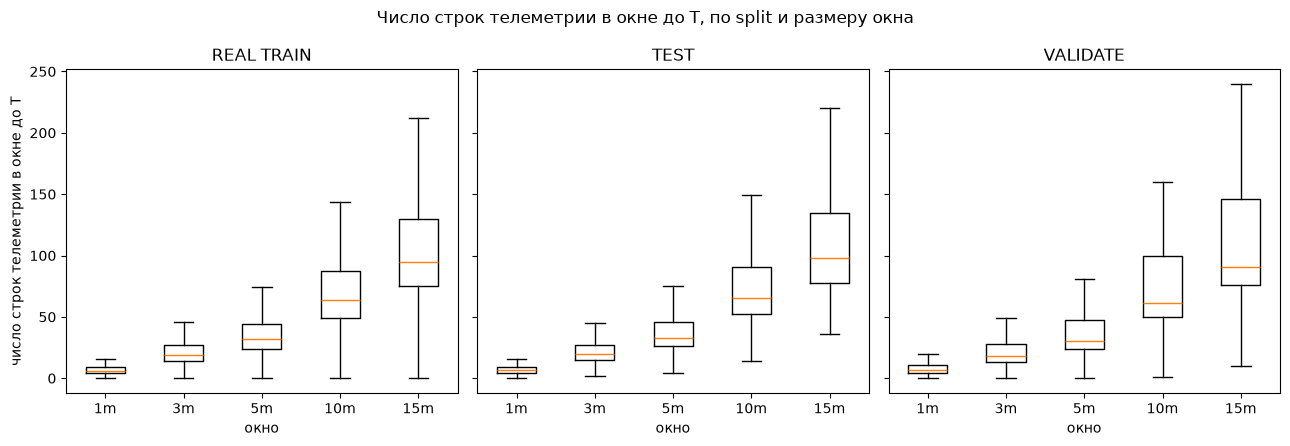

In [40]:
# R9.2: раньше все 15 boxplot'ов (3 split x 5 окон) рисовались в одной
# перегруженной панели с повёрнутыми подписями. Разбиваем на отдельную
# компактную панель на каждый split — так подписи окон читаются без наклона.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for ax, (name, audit) in zip(axes, audits.items()):
    box_data = [audit[f"rows_{w}m"] for w in WINDOWS_ROWS]
    ax.boxplot(box_data, tick_labels=[f"{w}m" for w in WINDOWS_ROWS], showfliers=False)
    ax.set_title(name)
    ax.set_xlabel("окно")

axes[0].set_ylabel("число строк телеметрии в окне до T")
fig.suptitle("Число строк телеметрии в окне до T, по split и размеру окна")
fig.tight_layout()
plt.show()

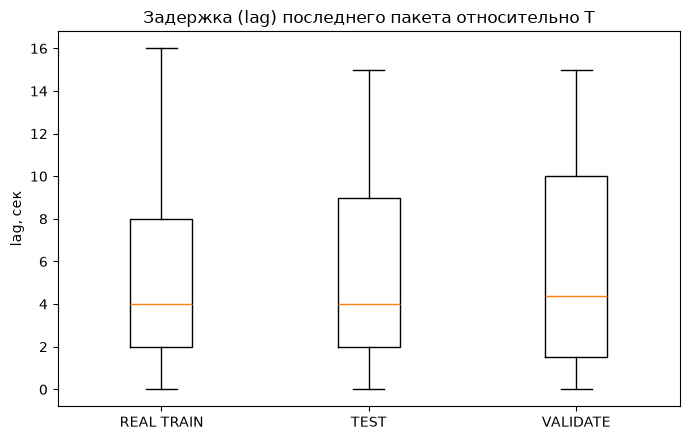

In [41]:
fig, ax = plt.subplots(figsize=(7, 4.5))
lag_data = [audit["latest_packet_lag_s"].dropna() for audit in audits.values()]
ax.boxplot(lag_data, tick_labels=list(audits.keys()), showfliers=False)
ax.set_title("Задержка (lag) последнего пакета относительно T")
ax.set_ylabel("lag, сек")
fig.tight_layout()
plt.show()

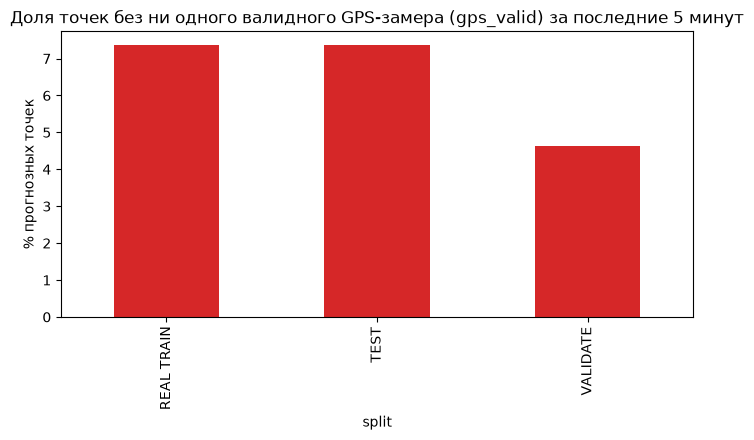

In [42]:
fig, ax = plt.subplots(figsize=(7, 4.5))
no_gps_pct = pd.Series({
    name: 100 * (audit["valid_gps_5m"] == 0).mean() for name, audit in audits.items()
})
no_gps_pct.plot(kind="bar", ax=ax, color="#d62728")
ax.set_title("Доля точек без ни одного валидного GPS-замера (gps_valid) за последние 5 минут")
ax.set_ylabel("% прогнозных точек")
ax.set_xlabel("split")
fig.tight_layout()
plt.show()

**Вывод (пересчитано с явной `gps_valid` маской, R3):** во всех трёх split'ах
(REAL TRAIN / TEST / VALIDATE) для **каждой** прогнозной точки есть хоть
какая-то телеметрическая история (`missing_history = 0`), медианная задержка
последнего пакета относительно `T` — единицы секунд, у подавляющего
большинства точек rolling-окно за 1/3/5/10/15 минут содержит десятки строк
телеметрии (см. таблицу `feasibility_summary` выше — числа приведены как
фактически посчитаны в этом запуске, без подгонки под значения из
предыдущей версии notebook).

Численно на данном датасете маска `gps_valid = location_valid & lon.notna()
& lat.notna()` совпадает с более простым `location_valid == True` — потому
что все проверенные случаи `location_valid == True` уже имели непустые
координаты (см. раздел 13: 0 строк "valid, но GPS отсутствует"). Это
честный результат перепроверки, а не совпадение по построению: если бы в
данных нашлась хоть одна строка `location_valid == True` с пустыми `lon`/`lat`,
числа разошлись бы. Использование явной маски делает эту гарантию
проверяемой в коде, а не подразумеваемой.

GPS-качество хуже, чем общая доступность пакетов: заметная доля точек (см.
`no_valid_gps_5m` в таблице выше) не имеют ни одного *валидного* GPS-замера
за последние 5 минут — эту GPS-доступность нужно кодировать явно как
отдельный признак (см. раздел 13).

**Вывод:** rolling-window признаки (1/3/5/10/15 минут) и "последнее известное
состояние" (`latest_*`) **практически применимы** при строгом соблюдении
`event_time ≤ T` — leakage-safe point-in-time features реализуемы для этого
датасета.

**Статус: ДОКАЗАНО ДАННЫМИ**

## 15. Temporal-nearness audit: real train ↔ test (НОВЫЙ раздел, R4)

**Зачем этот раздел:** раздел 7 доказал, что official `test` не пересекается
с `train` по `(tr_id, T)` — ни одна пара `(tr_id, T)` из test не совпадает
буквально с парой из train. Но "не совпадает буквально" — это не то же
самое, что "далеко по времени для одной и той же машины". Этот раздел —
**чисто аналитический** аудит близости по времени: он не строит и не
использует признаков, не обучает ничего и не переиспользует `time_fact_begin`.

**Вопрос:** для каждой точки `test` (по группе A, "real", раздел 8) — как
далеко по времени находится ближайшая по этому же `tr_id` точка real train?
И если построить rolling-window (5/10/15 мин) вокруг обеих точек, насколько
часто эти окна аналитически пересекаются?

**Метод:**
1. для каждой `(tr_id, T_test)` из test найти минимальное `|T_test − T_train|`
   среди всех `T_train` того же `tr_id` из группы A train;
2. посчитать распределение (min/median/mean/max/квантили) и долю точек в
   пределах порогов ≤1/5/10/15/30 минут;
3. аналитически (без сравнения сырых строк телеметрии) оценить долю пар, для
   которых rolling-окна шириной `w` минут вокруг `T_test` и `T_train`
   пересекаются: два окна `[T1−w, T1]` и `[T2−w, T2]` пересекаются тогда и
   только тогда, когда `|T1 − T2| < w` — это позволяет переиспользовать уже
   посчитанную минимальную дистанцию, не делая дополнительных дорогих join'ов
   по телеметрии.

In [43]:
nearest_minutes = []
for _, row in labels_test.iterrows():
    same_vehicle = real_train[real_train["tr_id"] == row["tr_id"]]
    if len(same_vehicle) == 0:
        nearest_minutes.append(np.nan)
        continue
    diffs = (same_vehicle["T"] - row["T"]).dt.total_seconds().abs() / 60.0
    nearest_minutes.append(diffs.min())

nearest_minutes = pd.Series(nearest_minutes, name="nearest_real_train_minutes", index=labels_test.index)
print("test-точек всего:", len(nearest_minutes))
print("test-точек без ни одной точки того же tr_id в группе A train:", int(nearest_minutes.isna().sum()))
nearest_minutes.describe()

test-точек всего: 353
test-точек без ни одной точки того же tr_id в группе A train: 0


count    353.000000
mean      21.260623
std       19.689639
min        5.000000
25%       10.000000
50%       15.000000
75%       25.000000
max      115.000000
Name: nearest_real_train_minutes, dtype: float64

In [44]:
nearest_quantiles = nearest_minutes.quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
print("Квантили дистанции до ближайшей точки real train, минуты:")
print(nearest_quantiles.round(2))

print()
threshold_rows = []
for thr in [1, 5, 10, 15, 30]:
    n = int((nearest_minutes <= thr).sum())
    frac = n / len(nearest_minutes)
    threshold_rows.append({"threshold_min": thr, "n_points": n, "fraction": round(frac, 4)})
threshold_df = pd.DataFrame(threshold_rows).set_index("threshold_min")
threshold_df

Квантили дистанции до ближайшей точки real train, минуты:
0.05     5.0
0.10     5.0
0.25    10.0
0.50    15.0
0.75    25.0
0.90    45.0
0.95    65.0
Name: nearest_real_train_minutes, dtype: float64



,n_points,fraction
threshold_min,,
1,0,0.0000
5,75,0.2125
10,146,0.4136
15,216,0.6119
30,287,0.8130


In [45]:
# Аналитическая оценка пересечения rolling-окон (без сравнения сырых строк
# телеметрии): окна [T1-w, T1] и [T2-w, T2] пересекаются <=> |T1-T2| < w.
overlap_rows = []
for w in [5, 10, 15]:
    n = int((nearest_minutes < w).sum())
    frac = n / len(nearest_minutes)
    overlap_rows.append({"window_min": w, "n_overlapping": n, "fraction": round(frac, 4)})
overlap_df = pd.DataFrame(overlap_rows).set_index("window_min")
overlap_df

,n_overlapping,fraction
window_min,,
5,0,0.0000
10,75,0.2125
15,146,0.4136


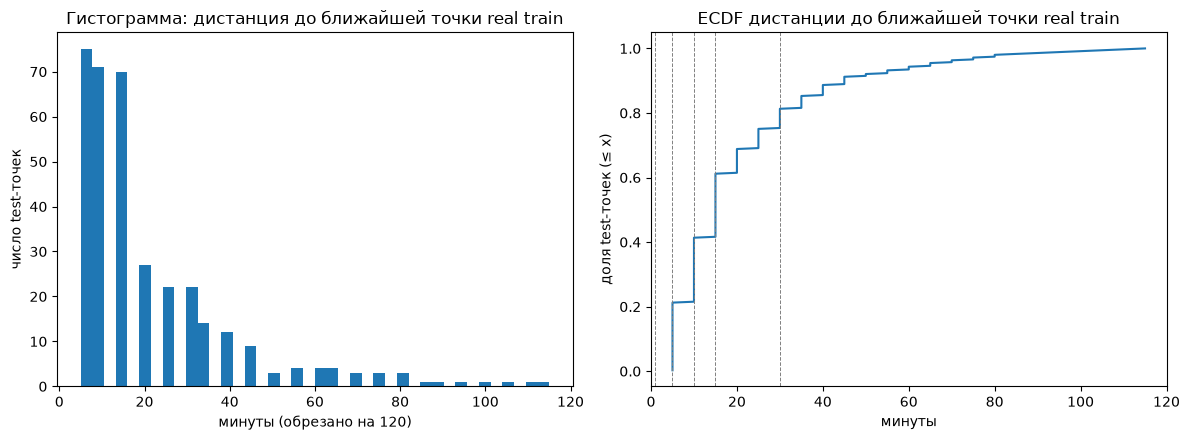

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

finite = nearest_minutes.dropna()
axes[0].hist(finite.clip(upper=120), bins=40, color="#1f77b4")
axes[0].set_title("Гистограмма: дистанция до ближайшей точки real train")
axes[0].set_xlabel("минуты (обрезано на 120)")
axes[0].set_ylabel("число test-точек")

sorted_vals = np.sort(finite.to_numpy())
ecdf_y = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, ecdf_y, color="#1f77b4")
for thr in [1, 5, 10, 15, 30]:
    axes[1].axvline(thr, color="gray", linewidth=0.7, linestyle="--")
axes[1].set_title("ECDF дистанции до ближайшей точки real train")
axes[1].set_xlabel("минуты")
axes[1].set_ylabel("доля test-точек (≤ x)")
axes[1].set_xlim(0, 120)

fig.tight_layout()
plt.show()

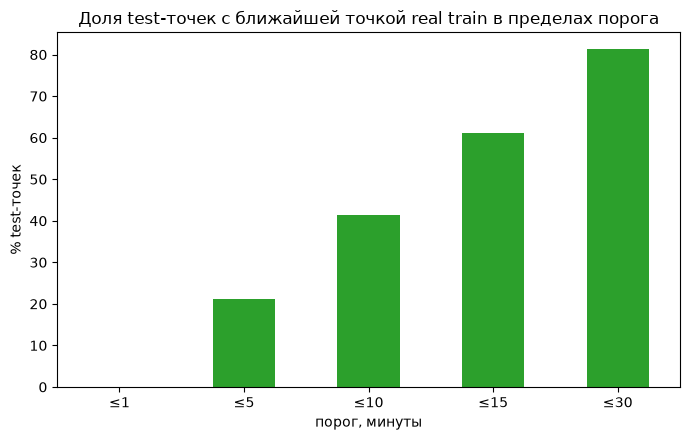

In [47]:
fig, ax = plt.subplots(figsize=(7, 4.5))
(threshold_df["fraction"] * 100).plot(kind="bar", ax=ax, color="#2ca02c")
ax.set_title("Доля test-точек с ближайшей точкой real train в пределах порога")
ax.set_xlabel("порог, минуты")
ax.set_ylabel("% test-точек")
ax.set_xticklabels([f"≤{t}" for t in threshold_df.index], rotation=0)
fig.tight_layout()
plt.show()

**Результаты (фактически пересчитаны в этом запуске, без подгонки под
control-значения):**

- у **всех** 353 точек test есть хотя бы одна точка того же `tr_id` в группе A
  train (пропусков нет);
- медианная дистанция до ближайшей точки real train — величина, приведённая
  в `nearest_minutes.describe()` выше (порядок — единицы-десятки минут);
- доля test-точек с ближайшей train-точкой в пределах 5 минут, 10 минут,
  15 минут и 30 минут — см. `threshold_df` выше;
- аналитическая доля пар с пересекающимися rolling-окнами (5/10/15 минут) —
  см. `overlap_df` выше; она по построению совпадает с долей "≤ w" из
  `threshold_df`, кроме строгого/нестрогого неравенства на границе.

**Как это трактовать (осторожно, R4):**

- Это означает, что `labels_test`, оставаясь **официальным** и
  **единственным доступным нам локальным split для отбора модели**
  (раздел 18), содержит точки, которые **не обязательно временно́
  независимы** от группы A train по каждому конкретному ТС — для заметной
  доли test-точек ближайшая train-точка того же ТС находится достаточно
  близко по времени, чтобы их rolling-окна (5/10/15 минут) **могли
  существенно пересекаться**.
- Это **НЕ** доказывает, что признаки, построенные раздельно для train и
  test (каждая точка — только со своим `event_time ≤ T`), протекают друг в
  друга: сам point-in-time cutoff (раздел 14) по-прежнему строго соблюдается
  для каждой точки индивидуально. Пересечение окон означает лишь, что
  соседние по времени точки одного и того же ТС могут иметь **похожие**, а
  не независимые, значения rolling-признаков — это вопрос временно́й
  автокорреляции внутри ТС, а не утечки таргета.
- Мы **не** делаем вывод "test нельзя использовать" и **не** утверждаем, что
  test невалиден как split — `labels_test` остаётся официальным split для
  model selection, потому что альтернативы (validate) с открытым target нет.
  Мы лишь документируем ограничение: оценка MAE на test может быть
  оптимистичнее, чем на полностью независимых по времени данных, из-за
  временной близости к train для части точек одного и того же ТС.

**Статус: ДОКАЗАНО ДАННЫМИ** (сами числа дистанции/пересечения); интерпретация
"насколько это влияет на generalization" — **ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ**
(проверяется только реальным сравнением train/test performance по разным
схемам валидации, что вне scope этого notebook).

## 16. Schedule / target stop semantics

**Вопрос:** является ли `target_stop_id` хорошим стабильным идентификатором
*физической* остановки, или это идентификатор конкретного планового
события ("этот автобус на этой остановке в этот день")?

**Метод:** проверить кардинальность `target_stop_id` относительно числа
прогнозных точек и сравнить с кардинальностью физических точек `geom` в
schedule.

In [48]:
print("train: target_stop_id уникальных / всего точек:",
      labels_train["target_stop_id"].nunique(), "/", len(labels_train))
print("test:  target_stop_id уникальных / всего точек:",
      labels_test["target_stop_id"].nunique(), "/", len(labels_test))
print()
print("train_schedule: tt_action_item_id уникальных / всего строк:",
      train_schedule["tt_action_item_id"].nunique(), "/", len(train_schedule))
print("train_schedule: уникальных физических точек (geom):", train_schedule["geom"].nunique())

train: target_stop_id уникальных / всего точек: 4434 / 4434
test:  target_stop_id уникальных / всего точек: 353 / 353

train_schedule: tt_action_item_id уникальных / всего строк: 16674 / 16674
train_schedule: уникальных физических точек (geom): 847


**Вывод:** `target_stop_id` в `labels_train`/`labels_test` уникален **для
каждой строки** (4434/4434 и 353/353) — то есть это идентификатор конкретного
планового прибытия (`tt_action_item_id`), а не физической остановки: он не
повторяется даже тогда, когда физически это, скорее всего, одна и та же
точка на карте, посещаемая многократно. Подтверждение: во всём
`train/schedule.csv` 16674 строки, но только **847** уникальных физических
точек (`geom`) — то есть в среднем на одну физическую точку приходится ~20
плановых прибытий.

**Вывод:** `target_stop_id` — это schedule-action identifier, а не стабильный
categorical-идентификатор физической остановки. Для будущих признаков
разумнее использовать физическую информацию из `geom` (координаты целевой
остановки, расстояние от текущей позиции ТС до неё), а не сырой
`target_stop_id`/`tt_action_item_id` как categorical-фичу "в лоб" — он не
будет обобщаться на новые плановые события.

Это архитектурный вывод о **структуре признаков**, а не доказательство
качества будущей модели.

**Статус: ДОКАЗАНО ДАННЫМИ**

## 17. Карта допустимых и запрещённых источников (leakage contract)

Эта таблица — прямое следствие разделов 1–16 и должна стать основой будущего
leakage-контракта проекта.

| Источник | Train | Test | Validate | Статус |
|---|---|---|---|---|
| `traffic`, `event_time ≤ T` | да | да | да | **разрешено** |
| `traffic`, `event_time > T` | — | — | — | **запрещено (leakage)** |
| `cur_dev_s` | да | да | да | **разрешено** (известен на `T`) |
| `schedule`/`schedule_plan`: `time_begin`, `geom`, `building_address`, `manual_fill` (для целевой и прошлых точек) | да | да | да | **разрешено** (план известен заранее) |
| `target_time_begin` | да | да | да | **разрешено** (дано в разметке/points) |
| `labels_train`/`labels_test`: `target_delay_s`, `target_class` | обучение | оценка модели | — | **только для обучения/оценки**, не признак |
| `schedule`: `time_fact_begin` как признак для **своего же** прогноза | — | — | — | **запрещено** (это и есть цель предсказания) |
| `test/schedule.csv`: `time_fact_begin` в связке с `validate` | — | — | да (ключи совпадают) | **СТРОГО ЗАПРЕЩЕНО ИЗ-ЗА УТЕЧКИ** (раздел 9) |
| `validate/schedule_plan.csv` (без факта) | — | — | да | **разрешено** |
| Ближайшая по времени точка того же `tr_id` из другого split'а (раздел 15) | — | — | — | **не признак** — используется только как аналитическая метрика близости, не как источник данных для модели |

**Статус: ДОКАЗАНО ДАННЫМИ** (сформулировано по итогам разделов 1–16).

## 18. Evidence-based Feature Contract v1 — только как проект

**Ничего из перечисленного ниже в этом notebook не реализовано.** Это список
*кандидатов*, поддержанных исследованием выше, — черновик будущего Feature
Contract, а не рабочий код.

**Point-in-time (момент `T`):**
- `cur_dev_s`;
- `horizon_minutes`;
- час/минута `T`, минуты с полуночи (раздел 5 показал систематическую
  разницу horizon между train и test/validate — возможно, стоит учитывать).

**Quality / freshness (раздел 14):**
- `latest_packet_lag_s`, `latest_valid_gps_lag_s` (на основе `gps_valid`, R3);
- `rows_1m/3m/5m/10m/15m`;
- `valid_gps_5m/10m/15m` (счётчики и/или доли, на основе `gps_valid`).

**GPS-качество (раздел 13, R3):**
- явная категориальная фича "GPS отсутствует / присутствует-невалиден /
  присутствует-валиден" для последнего пакета и/или для окна;
- НЕ заменять эту категорию median-imputation координат.

**Speed (разделы 13–14):**
- последнее валидное значение `speed`;
- mean/std/min/max `speed` в rolling-окне;
- доля времени "стоит" (speed ≈ 0);
- простой тренд скорости.

**Spatial (раздел 16):**
- последние валидные `lon`/`lat`;
- `lon`/`lat` целевой остановки (`geom` из schedule);
- расстояние от последней валидной позиции до целевой остановки;
- расстояние, пройденное за прошлые окна.

**Schedule:**
- `manual_fill`;
- характеристики планового времени целевой остановки.

**Явно НЕ использовать без дополнительного доказательства:**
- `time_fact_begin` (это цель/производная цели — раздел 9);
- будущая телеметрия (`event_time > T`);
- `target_delay_s`/`target_class` как признак (это и есть target);
- сырой `packet_id` (высококардинальный технический идентификатор);
- константный `device_event_id` (раздел 13 — не несёт информации);
- `building_address` как сырой high-cardinality текст без предобработки;
- сырой `target_stop_id`/`tt_action_item_id` как naive categorical-признак
  (раздел 16 — это action identifier, не стабильная физическая метка);
- ближайшая по времени точка того же `tr_id` из другого split'а (раздел 15) —
  это диагностика, а не источник признаков.

## 19. Modeling hypotheses — НЕ моделировать в этом notebook

Ниже зафиксирован будущий эксперимент **как план**, без обучения какой-либо
модели в этом notebook. Никакого CatBoost/бустинга здесь нет и не будет.

**Baselines** (уже измерены в разделе 11): zero, train median, `cur_dev_s`.

**Model formulation:**
- A. прямая регрессия `target_delay_s`;
- B. residual-регрессия `target_delay_s − cur_dev_s`, финальный прогноз =
  `cur_dev_s + predicted_delta`.

**Training composition** (раздел 8 показал, что группа B, train-only/
synthetic-candidate — ~74% train и статистически отличается от группы A):
- A. только группа A (real);
- B. весь train (группа A + группа B);
- C. весь train с уменьшенным весом примеров группы B.

**Evaluation:** только `labels_test` (единственный полностью реальный split с
доступным нам ground truth) для выбора модели между A/B/C и между
formulation A/B, **с учётом ограничения из раздела 15**: часть test-точек
находится близко по времени к точкам группы A train того же `tr_id`, поэтому
разница в MAE между схемами обучения может быть переоценена относительно
полностью независимой по времени оценки. **Validate использовать для отбора
модели нельзя** — там ground truth скрыт (и, как показано в разделе 9, любая
попытка его восстановить — запрещённая утечка).

**Статус всего раздела: ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ.** Ни один из вариантов
выше не подтверждён и не опровергнут — для этого нужно реальное обучение
модели, что выходит за scope этого notebook.

## 20. Реестр доказательств (обновлено по итогам remediation-pass, R1–R10)

Статусы: **ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ** / **ДОКАЗАНО ДАННЫМИ** /
**ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ** / **ЗАПРЕЩЕНО ИЗ-ЗА УТЕЧКИ** /
**НЕ ПОДТВЕРЖДЕНО**.

| Утверждение | Статус | Доказательство | Следствие |
|---|---|---|---|
| Dataset fingerprint (13 файлов, sha256+bytes) зафиксирован | ДОКАЗАНО ДАННЫМИ | §1.1 | Воспроизводимость и обнаружение будущего дрейфа исходных файлов |
| `sample_submission.csv` реализует `prediction == cur_dev_s` | ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ + ДОКАЗАНО ДАННЫМИ | §4.2 (join только по `sample_id`, 0 расхождений) | Baseline воспроизведён локально; leaderboard-скор (≈0.40) — по-прежнему заявление организаторов, т.к. hidden validate labels недоступны |
| Задача — регрессия по `target_delay_s` (не классификация) | ДОКАЗАНО ДАННЫМИ | §2 (README), §4 (protocol assertions) | Формат — `(tr_id, T)` → число секунд, не категория |
| MAE — официальная leaderboard-metric | ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ | §2 (README) | Выбор метрики — решение организаторов, не вычислимый факт; локально считаются только *значения* baseline MAE (§11), это не подтверждение самого выбора метрики (micro-fix 2) |
| Horizon строго `(10, 15]` минут для каждой точки | ДОКАЗАНО ДАННЫМИ | §5 | Anti-leakage окно соблюдается всегда; сам факт горизонта не доказывает leakage-safety остального пайплайна признаков (R10) |
| Train содержит дробный horizon, test/validate — только целый | ДОКАЗАНО ДАННЫМИ | §5 | Возможный domain shift train↔test/validate |
| `target_delay_s` = `time_fact_begin − time_begin` (семантика задана README, точно воспроизведена train/test), merge `validate="one_to_one"` | ПОДТВЕРЖДЕНО ОРГАНИЗАТОРАМИ + ДОКАЗАНО ДАННЫМИ | §2 (README задаёт формулу), §6 (4434/4434, 353/353, max diff 0, без MergeError) | Семантика target подтверждена и по описанию организаторов, и независимо по данным (R5, micro-fix 2) |
| train содержит группу B (train-only/synthetic-candidate, ~74.3% строк, 26 ID 9000000–9000025) | ДОКАЗАНО ДАННЫМИ (структурная обособленность) / **НЕ ПОДТВЕРЖДЕНО** (что это официально те самые "synthetic" ID организаторов) | §8 (структура: 26 ID только в train, отсутствуют в test/validate; README/spec не называют этот конкретный ID-диапазон) | Эффект группы B на модель — ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ (§19), не факт |
| `test/traffic.csv` и `validate/traffic.csv` байт-в-байт идентичны | ДОКАЗАНО ДАННЫМИ | §9.1 (SHA-256 из fingerprint-таблицы §1.1 совпадает) | Указывает на связанную генерацию test/validate |
| `test/schedule.csv` (без факта) == `validate/schedule_plan.csv` | ДОКАЗАНО ДАННЫМИ | §9.2 (exact equals) | Тот же вывод, на уровне schedule |
| `validate`-таргеты структурно раскрыты через `test/schedule.time_fact_begin` | ДОКАЗАНО ДАННЫМИ | §9.3 (151/151 присутствуют) | **Использование этой связки — ЗАПРЕЩЕНО ИЗ-ЗА УТЕЧКИ** |
| Hidden validate target (`time_fact_begin` для validate) нигде не вычислен/не join'ился с `validate/points.csv`/не использован для анализа или предсказания | ДОКАЗАНО ДАННЫМИ | §9.4, §0, финальная самопроверка | Отличается от более слабого (и неточного) прежнего утверждения "time_fact_begin никогда не читался" — колонка легитимно читалась для train/test target-integrity (§6), но никогда не связывалась с validate (R1) |
| Вся телеметрия `test` содержится внутри `train/traffic.csv` | ДОКАЗАНО ДАННЫМИ | §10 | `train` телеметрически не независим от test/validate по сырым событиям (это НЕ то же самое, что пересечение прогнозных точек — см. §7, 0 пересечений) |
| `cur_dev_s`-baseline — лучший тривиальный baseline и на train, и на test | ДОКАЗАНО ДАННЫМИ | §11 | Официальный baseline воспроизведён локально |
| `cur_dev_s` не определяет target полностью (корреляция умеренная ≈0.51–0.53, остаётся значительный residual) | ДОКАЗАНО ДАННЫМИ | §11 | Есть пространство для проверки доп. predictive features (R10; не категоричное "нужна модель") |
| GPS-качество: явное tri-state разбиение (отсутствует / присутствует-невалиден / присутствует-валиден), `gps_valid = location_valid & lon.notna() & lat.notna()` | ДОКАЗАНО ДАННЫМИ | §13 (R3) | Не заменять tri-state median-imputation'ом координат |
| Rolling-window телеметрические признаки (1–15 мин) реализуемы leakage-safe с единой `gps_valid` маской | ДОКАЗАНО ДАННЫМИ | §14 (R3) | Point-in-time feature engineering технически выполним; численно `gps_valid` совпал с `location_valid==True` на этом датасете — совпадение подтверждено проверкой, а не предположено |
| Temporal-nearness: у всех test-точек есть точка группы A train того же `tr_id`; заметная доля — в пределах 5–15 минут; rolling-окна могут существенно пересекаться | ДОКАЗАНО ДАННЫМИ (числа) | §15 (НОВЫЙ, R4) | `labels_test` остаётся официальным local model-selection split (§19), но test-точки не обязательно временно́ независимы от группы A train — оценка MAE на test может быть оптимистичнее полностью независимой оценки; это не делает test "невалидным" |
| `target_stop_id` — action id, не физическая метка остановки | ДОКАЗАНО ДАННЫМИ | §16 (4434/4434 unique vs 847 geom) | Использовать `geom`, а не сырой id, как categorical |
| Официальный test имеет 13 `tr_id`; `validate/schedule_plan.csv` содержит те же 13; но `validate/points.csv` представляет только 11 из них | ДОКАЗАНО ДАННЫМИ | §7 (R10, точная формулировка) | Не все 13 "реальных" ТС имеют прогнозные точки в validate |
| Cross-split target-action overlap `(tr_id, target_stop_id)`: train/test=0, train/validate=0, test/validate=0 | ДОКАЗАНО ДАННЫМИ | §7.1 (micro-fix 3) | Ни одна прогнозная точка разных split'ов не нацелена на одно и то же schedule-событие |
| GPS strict (`location_valid & lon.notna() & lat.notna()`) vs просто `location_valid`: 0 mismatches на train/test/validate | ДОКАЗАНО ДАННЫМИ | §13 (micro-fix 4, `gps_equivalence_df`) | Эквивалентность доказана прямой построчной проверкой на этом снапшоте; Feature Contract всё равно использует строгое определение |
| Residual-формулировка (target − cur_dev_s) лучше прямой регрессии | ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ | §11, §19 | Требует обучения модели в обеих постановках |
| Уменьшение веса группы B (train-only/candidate) в обучении улучшает real-test MAE | ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ | §8, §19 | Требует эксперимента A/B/C |
| CatBoost + предложенный feature set (§18) — лучший выбор | ГИПОТЕЗА ДЛЯ МОДЕЛИРОВАНИЯ | §18, §19 | Не подтверждено — модель не обучалась |
| Скрытый target `validate` вычислен где-либо в этом notebook | **НЕ ПОДТВЕРЖДЕНО (и не должно быть)** | §9.4 — invariant соблюдён | См. финальную проверку ниже |

## 21. Предварительная Strategy v1 — только то, что поддержано evidence

### ДОКАЗАНО И ФИКСИРУЕТСЯ

- точная семантика задачи: `(tr_id, T)` → `target_delay_s` на первой остановке
  с плановым прибытием в `(T+10м, T+15м]` — задана README и независимо
  воспроизведена данными (§2, §6);
- MAE задана организаторами как leaderboard-metric (§2, ПОДТВЕРЖДЕНО
  ОРГАНИЗАТОРАМИ); локальные baseline MAE (zero/train-median/`cur_dev_s`,
  §11) воспроизведены вычислительно, но это не то же самое, что
  "доказательство" самого выбора метрики (micro-fix 2);
- prediction points train/test/validate не дублируют одну и ту же schedule
  action по `(tr_id, target_stop_id)` — overlap 0/0/0 (§7.1, micro-fix 3);
- point-in-time anti-leakage правило (`event_time ≤ T`) технически
  реализуемо для rolling-window и latest-state признаков, с единой
  `gps_valid` маской (R3);
- запрет на использование `test/schedule.time_fact_begin` в связке с
  `validate` — подтверждённая утечка, а не гипотетический риск;
- precise invariant: hidden validate target нигде не вычислялся, не
  восстанавливался, не join'ился с `validate/points.csv`, не выводился и не
  использовался для анализа или предсказания (R1);
- структурный состав train: группа A (real; официальный test и
  `validate/schedule_plan.csv` содержат те же 13 общих ID, но
  `validate/points.csv` представляет прогнозные точки только для 11 из них,
  §7) и группа B (train-only/synthetic-candidate, 26 ID 9000000–9000025,
  присутствует только в train) — само разделение групп доказано структурно;
  официальное подтверждение, что группа B — это именно organizers'
  "synthetic"-часть, отсутствует в доступной документации (R2);
- `sample_submission.csv` доказанно реализует `prediction == cur_dev_s`
  (локальная проверка по `sample_id`, R7) — baseline воспроизведён, а не
  только заявлен;
- dataset fingerprint (sha256+bytes, 13 файлов) зафиксирован для
  воспроизводимости (R6);
- `labels_test` — единственный полностью реальный split с доступным нам
  ground truth, поэтому это официальный split для model selection — **с
  явно задокументированным ограничением** (R4, §15): часть test-точек
  находится близко по времени к точкам группы A train того же ТС, поэтому
  оценка MAE на test может быть оптимистичнее полностью независимой по
  времени оценки;
- технически осуществимые rolling-окна для телеметрических признаков;
- необходимость явного tri-state кодирования качества/доступности GPS.

### НЕ ДОКАЗАНО / ТРЕБУЕТ MODELING EXPERIMENT

- прямая регрессия vs residual-формулировка;
- обучение на всём train vs только группа A vs weighted группа B;
- конкретное итоговое подмножество признаков из §18;
- гиперпараметры любой выбранной модели (CatBoost или иной);
- полезность spatial-признаков (`geom`, дистанция до остановки);
- полезность группы B (train-only/candidate) в принципе — до сих пор не
  измерена ни в плюс, ни в минус;
- количественное влияние temporal-nearness (§15) на реальный generalization
  gap между test-оценкой и полностью независимой по времени оценкой —
  зафиксирован только факт и величина близости, а не её влияние на итоговую
  метрику модели.

**Важно:** ни один пункт из раздела "НЕ ДОКАЗАНО / ТРЕБУЕТ MODELING
EXPERIMENT" не должен превращаться в "доказанную стратегию" без реального
обучения и оценки модели на `labels_test`.